# Initialization

Please run all of the cells in this section before proceeding in the notebook. This will import all necessary packages and define functions used throughout the notebook.

## Imports

In [2]:
using Base.Threads, SparseArrays, KrylovKit, LinearAlgebra, Plots, DataFrames, LsqFit, ProgressMeter, JLD, Profile, BenchmarkTools, Einsum, Optim, Graphs, GraphPlot, LaTeXStrings, Alert, Statistics

## Functions

In [3]:
function rot(origin, point, rot_angle)
    """
    Rotate a point counterclockwise by a given angle around a given origin.
    The angle should be given in radians.
    """
    ox, oy = origin
    px, py = point
    
    qx = ox + cos(rot_angle) * (px - ox) - sin(rot_angle) * (py - oy)
    qy = oy + sin(rot_angle) * (px - ox) + cos(rot_angle) * (py - oy)
    
    return [qx, qy]
end;

In [4]:
function idx(i,j)
    return sum(row_lengths[1:j-1])+i
end;

function idx_inv(ind)
    register = row_lengths
    trial = 1
    while ind > register[trial]
        ind -= register[trial]
        trial += 1
    end
    
    return ind, abs(trial)
end;

function ind2space(index)
    i, j = idx_inv(index)
    pt = i*[sqrt(3)/2,0]+((i+1)%2)*[0,1/2]+j*[0,3/2]+j*[sqrt(3)/2,0]
    
    return pt - [sqrt(3),1.5]
end;

In [5]:
function ind2space_obc(index)
    i, j = idx_inv(index)
    if j < length(row_lengths)/2+1
        pt = i*[sqrt(3)/2,0]-((i+1)%2)*[0,1/2].+(maximum(row_lengths)-row_lengths[j])*[sqrt(3)/4,0].+j*[0,3/2]
    end
    
    if j > length(row_lengths)/2+1
        pt = (i*[sqrt(3)/2,0]+((i+1)%2)*[0,1/2].+(maximum(row_lengths)-row_lengths[j])*[sqrt(3)/4,0]+(j)*[0,3/2]).-[0,1/2]
    end   
    
    return pt
end;

In [6]:
function pbc_hamiltonian(L, Δ, tp, t, δϕ)
    rows = Int[]
    cols = Int[]
    data = Vector{Complex{Float64}}()
    
    len2 = length(row_lengths)
    
    for j in 1:length(row_lengths)
        len = row_lengths[j]
        for i in 1:len
            ### Nearest Neighbor ###
            # Intra-Row
            push!(rows, idx(mod1(i+1,len),j)); push!(cols, idx(i,j)); push!(data, t);
            push!(cols, idx(mod1(i+1,len),j)); push!(rows, idx(i,j)); push!(data, t);

            # Inter-Row
            if (i%2==0)
                push!(rows, idx(i-1,mod1(j+1,len2))); push!(cols, idx(i,j)); push!(data, t);
                push!(cols, idx(i-1,mod1(j+1,len2))); push!(rows, idx(i,j)); push!(data, t);
            end
            
            ### Next-Nearest Neighbor ###
            push!(rows, idx(mod1(i+2,len),j)); push!(cols, idx(i,j)); push!(data, -((-1)^(i))*im*tp/4);
            push!(cols, idx(mod1(i+2,len),j)); push!(rows, idx(i,j)); push!(data, +((-1)^(i))*im*tp/4);
    
            push!(rows, idx(mod1(i,len),mod1(j+1,len2))); push!(cols, idx(i,j)); push!(data, +((-1)^(i))*im*tp/4);
            push!(cols, idx(mod1(i,len),mod1(j+1,len2))); push!(rows, idx(i,j)); push!(data, -((-1)^(i))*im*tp/4);
            
            push!(rows, idx(mod1(i-2,len),mod1(j+1,len2))); push!(cols, idx(i,j)); push!(data, -((-1)^(i))*im*tp/4);
            push!(cols, idx(mod1(i-2,len),mod1(j+1,len2))); push!(rows, idx(i,j)); push!(data, +((-1)^(i))*im*tp/4);
            
            ### Staggered On-Site Potential ###
            ## Bottom ##
            push!(rows, idx(i,j)); push!(cols, idx(i,j)); push!(data, ((-1)^(i))*Δ);
        end
    end

    H = SparseArrays.sparse(rows, cols, data, L_tot, L_tot)

    return H
end;  

In [7]:
function obc_hamiltonian(L, Δ, tp, t, δϕ)
    rows = Int[]
    cols = Int[]
    data = Vector{Complex{Float64}}()

    for j in 1:length(row_lengths)
        len = row_lengths[j]
        for i in 1:len
            ### Nearest Neighbor ###
            # Intra-Row
            if (i<len)
                push!(rows, idx(i+1,j)); push!(cols, idx(i,j)); push!(data, t);
                push!(cols, idx(i+1,j)); push!(rows, idx(i,j)); push!(data, t);
            end

            # Inter-Row
            if (j < length(row_lengths))
                # Bottom
                if (row_lengths[j+1] > row_lengths[j])&&(i%2==1)
                    push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, t);
                    push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, t);
                end

                # Middle
                if (row_lengths[j+1] == row_lengths[j])&&(i%2==1)
                    if i > row_lengths[j]/2+1
                        push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, t*exp(-im*δϕ));
                        push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, t*exp(im*δϕ));
                    else
                        push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, t);
                        push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, t);
                    end
                end

                # Top
                if (row_lengths[j+1] < row_lengths[j])&&(i%2==0)
                    if (i>1)&&(i<(len))
                        push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, t);
                        push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, t);
                    end
                end
            end  
            
            ### Next-Nearest Neighbor ###
            ## Bottom ##
            if (j < length(row_lengths))&&(i < row_lengths[j]-1)
                if (row_lengths[j+1] > row_lengths[j])&&((j>1)||(i%2==1))
                    push!(rows, idx(i+2,j)); push!(cols, idx(i,j)); push!(data, +((-1)^i)*im*tp/4);
                    push!(cols, idx(i+2,j)); push!(rows, idx(i,j)); push!(data, -((-1)^i)*im*tp/4);
                end
            end
    
            if (j < length(row_lengths))&&(i < row_lengths[j+1]-2)
                if (row_lengths[j+1] > row_lengths[j])
                    push!(rows, idx(i+2,j+1)); push!(cols, idx(i,j)); push!(data, -((-1)^i)*im*tp/4);
                    push!(cols, idx(i+2,j+1)); push!(rows, idx(i,j)); push!(data, +((-1)^i)*im*tp/4);
                end
            end
            
            if (j < length(row_lengths)-1)&&(i < row_lengths[j+1]-1)&&(i>1)
                if (row_lengths[j+1] > row_lengths[j])
                    push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, +((-1)^i)*im*tp/4);
                    push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, -((-1)^i)*im*tp/4);
                end
            end

            ## Middle ##
            if (j < length(row_lengths)-1)&&(i < row_lengths[j]-1)
                if row_lengths[j+1] == row_lengths[j]
                    push!(rows, idx(i+2,j)); push!(cols, idx(i,j)); push!(data, +((-1)^i)*im*tp/4);
                    push!(cols, idx(i+2,j)); push!(rows, idx(i,j)); push!(data, -((-1)^i)*im*tp/4);
                end
            end
            
            if (j < length(row_lengths)-1)&&(i < row_lengths[j])
                if row_lengths[j+1] == row_lengths[j]
                    push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, -((-1)^i)*im*tp/4);
                    push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, +((-1)^i)*im*tp/4);
                end
            end
            
            if (j < length(row_lengths)-1)&&(i <= row_lengths[j])&&(i>1)
                if row_lengths[j+1] == row_lengths[j]
                    push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, +((-1)^i)*im*tp/4);
                    push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, -((-1)^i)*im*tp/4);
                end
            end

            ## Top ##
            if (j < length(row_lengths))&&(i < row_lengths[j]-1)
                if row_lengths[j+1] < row_lengths[j]
                    push!(rows, idx(i+2,j)); push!(cols, idx(i,j)); push!(data, -((-1)^i)*im*tp/4);
                    push!(cols, idx(i+2,j)); push!(rows, idx(i,j)); push!(data, +((-1)^i)*im*tp/4);
                end
            end
            
            if (j < length(row_lengths))&&(i < row_lengths[j]-1)&&(i>1)
                if row_lengths[j+1] < row_lengths[j]
                    push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, +((-1)^i)*im*tp/4);
                    push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, -((-1)^i)*im*tp/4);
                end
            end
            
            if (j < length(row_lengths))&&(i < row_lengths[j])&&(i>2)
                if row_lengths[j+1] < row_lengths[j]
                    push!(rows, idx(i-2,j+1)); push!(cols, idx(i,j)); push!(data, -((-1)^i)*im*tp/4);
                    push!(cols, idx(i-2,j+1)); push!(rows, idx(i,j)); push!(data, +((-1)^i)*im*tp/4);
                end
            end
            
            if (j >= length(row_lengths))&&(i < row_lengths[j]-1)&&(i%2==1)
                push!(rows, idx(i+2,j)); push!(cols, idx(i,j)); push!(data, -((-1)^i)*im*tp/4);
                push!(cols, idx(i+2,j)); push!(rows, idx(i,j)); push!(data, +((-1)^i)*im*tp/4);
            end


            ### Staggered On-Site Potential ###
            if (i%2==1)&&(j < Int(floor(length(row_lengths)/2+2)))
                push!(rows, idx(i,j)); push!(cols, idx(i,j)); push!(data, -Δ);
            elseif (i%2==0)&&(j >= Int(floor(length(row_lengths)/2+2)))
                push!(rows, idx(i,j)); push!(cols, idx(i,j)); push!(data, -Δ);
            else
                push!(rows, idx(i,j)); push!(cols, idx(i,j)); push!(data, Δ);
            end
            
        end
    end

    H = SparseArrays.sparse(rows, cols, data, L_tot, L_tot)

    return H
end;  

In [8]:
function make_rotation(origin_space)
    sites = []
    for i in 1:L_tot
        push!(sites,[ind2space(i)[1],ind2space(i)[2]])
    end
    sites = hcat(sites...)

    Dx = ind2space(idx(L,1))[1]+sqrt(3)/2
    Dy = ind2space(idx(2,length(row_lengths)))[2]+1

    rot_idx_list = []

    C3 = zeros((L_tot,L_tot))
    for ind in 1:L_tot
        i, j = idx_inv(ind)
        len = row_lengths[j]
        
        pt = ind2space(ind)
        rot_pt = rot(origin_space, pt, 2*pi/3)
        distance = abs.(sites .- [rot_pt[1],rot_pt[2]])
        result_list = dropdims(sum(distance,dims=1),dims=1)
        if minimum(result_list) < 1e-2
            push!(rot_idx_list,ind)
            rot_idx = argmin(result_list)
        else
            while rot_pt[2] > (L/2)*1.5+1e-1
                rot_pt -= [(L/2)*sqrt(3)/2,(L/2)*1.5]
            end
            
            while rot_pt[2] < -2e-1
                rot_pt += [(L/2)*sqrt(3)/2,(L/2)*1.5]
            end
            
            while rot_pt[1] < rot_pt[2]/(1.5/(sqrt(3)/2))-2e-1
                rot_pt += [L*sqrt(3)/2,0]
            end
            
            while rot_pt[1] > rot_pt[2]/(1.5/(sqrt(3)/2))+L*sqrt(3)/2-2e-1
                rot_pt -= [L*sqrt(3)/2,0]
            end
            
            distance = abs.(sites .- [rot_pt[1],rot_pt[2]])
            result_list = dropdims(sum(distance,dims=1),dims=1)
            rot_idx = argmin(result_list)
            
            push!(rot_idx_list,rot_idx)
        end
            
        C3[rot_idx,ind] = 1
    end

    return C3
end;

In [64]:
function visualize_pbc(h,t,tp,Δ,δϕ)
    
    p1 = plot(legend=false,size=(600,600))

    for idx1 in 1:L_tot
        for idx2 in 1:L_tot
            i, j = ind2space(idx1)
            ip, jp = ind2space(idx2)
            
            if round(h[idx2,idx1],digits=8) == t
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line, y_line, linewidth=2,linecolor=:black)
            end
            if round(h[idx2,idx1],digits=8) == -t
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line, y_line, linewidth=2,linecolor=:red)
            end
            if (δϕ!=0)&&(h[idx2,idx1] == -t*exp(im*δϕ))
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line, y_line, linewidth=2,linecolor=:purple,arrow=true)
            end
            if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*δϕ))
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line, y_line, linewidth=2,linecolor=:blue,arrow=true)
            end 

            if (tp!=0)&&(h[idx2,idx1] == tp/4*im)
                x_line = [i,ip]; y_line = [j,jp];
                plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:orange,arrow=true,alpha=0.3)
                plot!(x_line, y_line, linewidth=2,linecolor=:orange,alpha=0.3)
            end
            
            if (δϕ!=0)&&(tp!=0)&&(h[idx2,idx1] == tp/4*im*exp(-im*δϕ))
                x_line = [i,ip]; y_line = [j,jp];
                plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:gold,arrow=true,alpha=0.3)
                plot!(x_line, y_line, linewidth=2,linecolor=:gold,alpha=0.3)
            end
            
            if (δϕ!=0)&&(tp!=0)&&(h[idx2,idx1] == tp/4*im*exp(im*δϕ))
                x_line = [i,ip]; y_line = [j,jp];
                plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:darkorange3,arrow=true,alpha=0.3)
                plot!(x_line, y_line, linewidth=2,linecolor=:darkorange3,alpha=0.3)
            end
        end
    end
    
    if Δ != 0
        for idx1 in 1:L_tot
            i, j = ind2space(idx1)
            if h[idx1,idx1] == -Δ
                scatter!([i],[j],color=:black,markersize=5,markerstrokewidth=1)
            elseif h[idx1,idx1] == Δ
                scatter!([i],[j],color=:white,markersize=5,markerstrokewidth=1)
            end
        end
    end
    
    scatter!([origin_space_A[1]],[origin_space_A[2]],marker=:xcross,markerstrokewidth=3,markercolor=:black)
    
    plot!([0,(L/2)*sqrt(3)/2],[0,(L/2)*1.5],color=:red,linewidth=3)
    plot!([(L/2)*sqrt(3)/2,(L/2)*sqrt(3)/2+(L)*sqrt(3)/2],[(L/2)*1.5,(L/2)*1.5],color=:red,linewidth=3)
    plot!([0,(L)*sqrt(3)/2],[0,0],color=:red,linewidth=3)
    plot!([(L)*sqrt(3)/2,(L)*sqrt(3)/2+(L/2)*sqrt(3)/2],[0,(L/2)*1.5],color=:red,linewidth=3)
    
    plot(p1,layout=(1,1),size=(700,450),constrained_layout=true, axis = false, grid = false)
end;

In [65]:
function visualize_obc(h,t,tp,Δ,δϕ)
    p1 = plot(legend=false,size=(600,600))

    for idx1 in 1:L_tot
        for idx2 in 1:L_tot
            i, j = ind2space_obc(idx1)
            ip, jp = ind2space_obc(idx2)
            
            if round(h[idx2,idx1],digits=8) == t
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line, y_line, linewidth=2,linecolor=:black)
            end
            if round(h[idx2,idx1],digits=8) == -t
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line, y_line, linewidth=2,linecolor=:red)
            end
            if (δϕ!=0)&&(h[idx2,idx1] == -t*exp(im*δϕ))
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line, y_line, linewidth=2,linecolor=:purple,arrow=true)
            end
            if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*δϕ))
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:blue,arrow=true,alpha=1)
                plot!(x_line, y_line, linewidth=2,linecolor=:blue,alpha=1)
            end 

            if (tp!=0)&&(h[idx2,idx1] == tp/4*im)
                x_line = [i,ip]; y_line = [j,jp];
                plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:orange,arrow=true,alpha=1)
                plot!(x_line, y_line, linewidth=2,linecolor=:orange,alpha=1)
            end
        end
    end
    
    if Δ != 0
        for idx1 in 1:L_tot
            i, j = ind2space_obc(idx1)
            if h[idx1,idx1] == -Δ
                scatter!([i],[j],color=:black,markersize=5,markerstrokewidth=1)
            elseif h[idx1,idx1] == Δ
                scatter!([i],[j],color=:white,markersize=5,markerstrokewidth=1)
            end
        end
    end
    
    scatter!([origin_space[1]],[origin_space[2]],marker=:xcross,markerstrokewidth=3,markercolor=:black)
    
    plot(p1,layout=(1,1),size=(440,400),constrained_layout=true,axis=([], false))
end;

function disc_ind2space(index)
        return 100 .* indices[index,:]
    
    end;

In [11]:
function disc_idx(i,j,k)
    return sum(row_lengths[1:j-1])+i+(k-1)*L_subtotal
end;

function disc_idx_inv(ind)
    k = ceil(ind/L_subtotal)
    
    ind = mod1(ind,L_subtotal)
    
    register = row_lengths
    trial = 1
    while ind > register[trial]
        ind -= register[trial]
        trial += 1
    end
    
    return ind, abs(trial), k
end;

In [12]:
function disc_hamiltonian_A(L, Δ, tp, t, δϕ)
    idx = disc_idx
    
    rows = Int[]
    cols = Int[]
    data = Vector{Complex{Float64}}()

    for j in 1:length(row_lengths)
        len = row_lengths[j]
        for i in 1:len
            for k in 1:2
                ### Nearest Neighbor ###
                ## Intra-Wedge ##
                # Intra-Row #
                if (i<len)
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+1,j,k)); push!(cols, idx(i,j,k)); push!(data, t*exp(-im*δϕ));
                        push!(cols, idx(i+1,j,k)); push!(rows, idx(i,j,k)); push!(data, t*exp(im*δϕ));
                    elseif k == 1 && i==1+(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)&&j>length(row_lengths)/2
                        push!(rows, idx(i+1,j,k)); push!(cols, idx(i,j,k)); push!(data, t*exp(-im*δϕ));
                        push!(cols, idx(i+1,j,k)); push!(rows, idx(i,j,k)); push!(data, t*exp(im*δϕ));
                    else
                        push!(rows, idx(i+1,j,k)); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(i+1,j,k)); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                end

                # Inter-Row #
                if (j < length(row_lengths))
                    # Bottom
                    if (j<length(row_lengths)/2)&&(i%2==1)
                        push!(rows, idx(i+3,j+1,k)); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(i+3,j+1,k)); push!(rows, idx(i,j,k)); push!(data, t);
                    end

                    # Middle
                    if (j==length(row_lengths)/2)&&(i%2==1)
                        push!(rows, idx(i,j+1,k)); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(i,j+1,k)); push!(rows, idx(i,j,k)); push!(data, t);
                    end

                    # Top
                    if (j>length(row_lengths)/2)&&(i%2==0)
                        if (i>1)&&(i<(len))
                            push!(rows, idx(i-1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, t);
                            push!(cols, idx(i-1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, t);
                        end
                    end
                end  
                
                ## Inter-Wedge ##
                if j<length(row_lengths)/2
                    if i==1
                        push!(rows, idx(row_lengths[j+1]-1,j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(row_lengths[j+1]-1,j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                    
                    if i==2
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                end
                
                if j==length(row_lengths)/2
                    if i==1
                        push!(rows, idx(row_lengths[j+1],j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(row_lengths[j+1],j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                    
                    if i==2
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                end

                ### Next-Nearest Neighbor ###
                ## Intra-Wedge ##
                # Bottom #
                if (j<length(row_lengths)/2)&&(i<=len-2)
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2 && j>1
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==1+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                    end
                end

                if (j<length(row_lengths)/2)&&(i+2<=row_lengths[j+1])
                    push!(rows, idx(i+2,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    push!(cols, idx(i+2,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                end
                
                if (j<length(row_lengths)/2)&&(i+4<=row_lengths[j+1])
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+4,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+4,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==1+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+4,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+4,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+4,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        push!(cols, idx(i+4,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    end
                end

                # Middle #
                if (j==length(row_lengths)/2)&&(i<=len-2)
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==1+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                    end
                end
                
                if (j==length(row_lengths)/2)&&(i-1>=1)
                    push!(rows, idx(i-1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    push!(cols, idx(i-1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                end
                
                if (j==length(row_lengths)/2)&&(i+1<=row_lengths[j+1])
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==1+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        push!(cols, idx(i+1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    end
                end

                # Top #
                if (j>length(row_lengths)/2)&&(i<=len-2)&&(j<length(row_lengths)||i%2==1)
                    if k == 1 && i==1+(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    end
                end
                
                if (j+1<=length(row_lengths))
                    if (j>length(row_lengths)/2)&&(i<=row_lengths[j+1])&&i>1
                        if k == 1 && i==1+(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)
                            push!(rows, idx(i,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                            push!(cols, idx(i,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                        elseif k == 1 && i==(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)
                            push!(rows, idx(i,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                            push!(cols, idx(i,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                        else
                            push!(rows, idx(i,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                            push!(cols, idx(i,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        end
                    end
                    
                    if (j>length(row_lengths)/2)&&(i-2>0)&&i<len
                        push!(rows, idx(i-2,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        push!(cols, idx(i-2,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    end
                end
                
                ## Inter-Wedge ##
                if j<length(row_lengths)/2
                    if i==1
                        push!(rows, idx(row_lengths[j+1]-2,j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-2,j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                        
                        push!(rows, idx(row_lengths[j+1],j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j+1],j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                        
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                    end
                    
                    if i==2
                        push!(rows, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                        
                        push!(rows, idx(row_lengths[j+1]-3,j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-3,j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                        
                        push!(rows, idx(row_lengths[j+1]-1,j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-1,j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                    end
                    
                    if i==3
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                    end
                    
                    if i==4
                        push!(rows, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                    end
                end
                
                if j==length(row_lengths)/2
                    if i==1
                        push!(rows, idx(row_lengths[j+1]-1,j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-1,j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                        
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                    end
                    
                    if i==2
                        push!(rows, idx(row_lengths[j+1]-2,j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-2,j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                        
                        push!(rows, idx(row_lengths[j+1],j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j+1],j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                        
                        push!(rows, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                    end
                    
                    if i==3
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                    end
                    
                    if i==4
                        push!(rows, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                    end
                end
                
                
                ### Staggered On-Site Potential ###
                if (i%2==1)&&(j<=length(row_lengths)/2)
                    push!(rows, idx(i,j,k)); push!(cols, idx(i,j,k)); push!(data, Δ);
                elseif (i%2==0)&&(j>length(row_lengths)/2)
                    push!(rows, idx(i,j,k)); push!(cols, idx(i,j,k)); push!(data, Δ);
                else
                    push!(rows, idx(i,j,k)); push!(cols, idx(i,j,k)); push!(data, -Δ);
                end

            end
        end
    end
    
    ## Involving the Center
    
    push!(rows, L_tot); push!(cols, L_tot); push!(data, Δ);
    
    for k in 1:2
        push!(rows, L_tot); push!(cols, idx(4,1,k)); push!(data, t);
        push!(cols, L_tot); push!(rows, idx(4,1,k)); push!(data, t);
        
        push!(rows, L_tot); push!(cols, idx(3,1,k)); push!(data, im*tp/4);
        push!(cols, L_tot); push!(rows, idx(3,1,k)); push!(data, -im*tp/4);
        
        push!(rows, L_tot); push!(cols, idx(5,1,k)); push!(data, -im*tp/4);
        push!(cols, L_tot); push!(rows, idx(5,1,k)); push!(data, im*tp/4);
    end

    H = SparseArrays.sparse(rows, cols, data, L_tot, L_tot)

    return H
end;  

In [248]:
function disc_hamiltonian_B(L, Δ, tp, t, δϕ)
    idx = disc_idx

    rows = Int[]
    cols = Int[]
    data = Vector{Complex{Float64}}()

    for j in 1:length(row_lengths)
        len = row_lengths[j]
        for i in 1:len
            for k in 1:2
                ### Nearest Neighbor ###
                ## Intra-Wedge ##
                # Intra-Row #
                if (i<len)
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+1,j,k)); push!(cols, idx(i,j,k)); push!(data, t*exp(-im*δϕ));
                        push!(cols, idx(i+1,j,k)); push!(rows, idx(i,j,k)); push!(data, t*exp(im*δϕ));
                    elseif k == 1 && i==1+(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)&&j>length(row_lengths)/2
                        push!(rows, idx(i+1,j,k)); push!(cols, idx(i,j,k)); push!(data, t*exp(-im*δϕ));
                        push!(cols, idx(i+1,j,k)); push!(rows, idx(i,j,k)); push!(data, t*exp(im*δϕ));
                    else
                        push!(rows, idx(i+1,j,k)); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(i+1,j,k)); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                end

                # Inter-Row #
                if (j < length(row_lengths))
                    # Bottom
                    if (j<length(row_lengths)/2)&&(i%2==1)
                        push!(rows, idx(i+3,j+1,k)); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(i+3,j+1,k)); push!(rows, idx(i,j,k)); push!(data, t);
                    end

                    # Middle
                    if (j==length(row_lengths)/2)&&(i%2==1)
                        push!(rows, idx(i,j+1,k)); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(i,j+1,k)); push!(rows, idx(i,j,k)); push!(data, t);
                    end

                    # Top
                    if (j>length(row_lengths)/2)&&(i%2==0)
                        if (i>1)&&(i<(len))
                            push!(rows, idx(i-1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, t);
                            push!(cols, idx(i-1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, t);
                        end
                    end
                end  
                
                ## Inter-Wedge ##
                if j<length(row_lengths)/2
                    if i==1
                        push!(rows, idx(row_lengths[j+1]-1,j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(row_lengths[j+1]-1,j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                    
                    if i==2
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                end
                
                if j==length(row_lengths)/2
                    if i==1
                        push!(rows, idx(row_lengths[j+1],j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(row_lengths[j+1],j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                    
                    if i==2
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                end

                ### Next-Nearest Neighbor ###
                ## Intra-Wedge ##
                # Bottom #
                if (j<length(row_lengths)/2)&&(i<=len-2)
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2 && j>1
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==1+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                    end
                end

                if (j<length(row_lengths)/2)&&(i+2<=row_lengths[j+1])
                    push!(rows, idx(i+2,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    push!(cols, idx(i+2,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                end
                
                if (j<length(row_lengths)/2)&&(i+4<=row_lengths[j+1])
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+4,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+4,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==1+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+4,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+4,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+4,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        push!(cols, idx(i+4,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    end
                end

                # Middle #
                if (j==length(row_lengths)/2)&&(i<=len-2)
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==1+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                    end
                end
                
                if (j==length(row_lengths)/2)&&(i-1>=1)
                    push!(rows, idx(i-1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    push!(cols, idx(i-1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                end
                
                if (j==length(row_lengths)/2)&&(i+1<=row_lengths[j+1])
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==1+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        push!(cols, idx(i+1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    end
                end

                # Top #
                if (j>length(row_lengths)/2)&&(i<=len-2)&&(j<length(row_lengths)||i%2==1)
                    if k == 1 && i==1+(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    end
                end
                
                if (j+1<=length(row_lengths))
                    if (j>length(row_lengths)/2)&&(i<=row_lengths[j+1])&&i>1
                        if k == 1 && i==1+(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)
                            push!(rows, idx(i,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                            push!(cols, idx(i,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                        elseif k == 1 && i==(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)
                            push!(rows, idx(i,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                            push!(cols, idx(i,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                        else
                            push!(rows, idx(i,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                            push!(cols, idx(i,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        end
                    end
                    
                    if (j>length(row_lengths)/2)&&(i-2>0)&&i<len
                        push!(rows, idx(i-2,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        push!(cols, idx(i-2,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    end
                end
                
                ## Inter-Wedge ##
                if j<length(row_lengths)/2
                    if i==1
                        push!(rows, idx(row_lengths[j+1]-2,j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-2,j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                        
                        push!(rows, idx(row_lengths[j+1],j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j+1],j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                        
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                    end
                    
                    if i==2
                        push!(rows, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                        
                        push!(rows, idx(row_lengths[j+1]-3,j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-3,j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                        
                        push!(rows, idx(row_lengths[j+1]-1,j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-1,j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                    end
                    
                    if i==3
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                    end
                    
                    if i==4
                        push!(rows, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                    end
                end
                
                if j==length(row_lengths)/2
                    if i==1
                        push!(rows, idx(row_lengths[j+1]-1,j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-1,j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                        
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                    end
                    
                    if i==2
                        push!(rows, idx(row_lengths[j+1]-2,j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-2,j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                        
                        push!(rows, idx(row_lengths[j+1],j+1,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j+1],j+1,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                        
                        push!(rows, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                    end
                    
                    if i==3
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                    end
                    
                    if i==4
                        push!(rows, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j]-1,j,mod1(k+1,2))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                    end
                end
                
                
                ### Staggered On-Site Potential ###
                if (i%2==1)&&(j<=length(row_lengths)/2)
                    push!(rows, idx(i,j,k)); push!(cols, idx(i,j,k)); push!(data, -Δ);
                elseif (i%2==0)&&(j>length(row_lengths)/2)
                    push!(rows, idx(i,j,k)); push!(cols, idx(i,j,k)); push!(data, -Δ);
                else
                    push!(rows, idx(i,j,k)); push!(cols, idx(i,j,k)); push!(data, Δ);
                end

            end
        end
    end
    
    ## Involving the Center
    
    push!(rows, L_tot); push!(cols, L_tot); push!(data, -Δ);
    
    for k in 1:2
        push!(rows, L_tot); push!(cols, idx(4,1,k)); push!(data, t);
        push!(cols, L_tot); push!(rows, idx(4,1,k)); push!(data, t);
        
        push!(rows, L_tot); push!(cols, idx(3,1,k)); push!(data, im*tp/4);
        push!(cols, L_tot); push!(rows, idx(3,1,k)); push!(data, -im*tp/4);
        
        push!(rows, L_tot); push!(cols, idx(5,1,k)); push!(data, -im*tp/4);
        push!(cols, L_tot); push!(rows, idx(5,1,k)); push!(data, im*tp/4);
    end

    H = SparseArrays.sparse(rows, cols, data, L_tot, L_tot)

    return H
end;  

In [284]:
function disc_hamiltonian_C(L, Δ, tp, t, δϕ)
    idx = disc_idx

    rows = Int[]
    cols = Int[]
    data = Vector{Complex{Float64}}()

    for j in 1:length(row_lengths)
        len = row_lengths[j]
        for i in 1:len
            for k in 1:4
                ### Nearest Neighbor ###
                ## Intra-Wedge ##
                # Intra-Row
                if (i<len)
                    push!(rows, idx(i+1,j,k)); push!(cols, idx(i,j,k)); push!(data, t);
                    push!(cols, idx(i+1,j,k)); push!(rows, idx(i,j,k)); push!(data, t);
                end

                # Inter-Row
                if (j < length(row_lengths))
                    # Bottom
                    if (i%2==1)
                        push!(rows, idx(i+1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(i+1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                end  
                
                ## Inter-Wedge
                # Intra-Row
                if (i==len)
                    if k == 2
                        push!(rows, idx(i,j,k)); push!(cols, idx(1,j,mod1(k-1,4))); push!(data, exp(im*δϕ)*t);
                        push!(cols, idx(i,j,k)); push!(rows, idx(1,j,mod1(k-1,4))); push!(data, exp(-im*δϕ)*t);
                    else
                        push!(rows, idx(i,j,k)); push!(cols, idx(1,j,mod1(k-1,4))); push!(data, t);
                        push!(cols, idx(i,j,k)); push!(rows, idx(1,j,mod1(k-1,4))); push!(data, t);
                    end
                end
            
            ### Next-Nearest Neighbor ###
            ## Intra-Wedge ##
            if ((j < length(row_lengths))||((j == length(row_lengths))&&(i%2==0)))&&(i < row_lengths[j]-1)
                push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
            end
    
            if (j < length(row_lengths))&&(i < row_lengths[j+1]-2)
                push!(rows, idx(i+2,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                push!(cols, idx(i+2,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
            end
            
            if (j < length(row_lengths))&&(i>1)
                push!(rows, idx(i,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                push!(cols, idx(i,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
            end
                
            ## Inter-Wedge ##
            if (i==len)&&(1<j<=length(row_lengths))
                if k == 2
                    push!(rows, idx(i,j,k)); push!(cols, idx(2,j,mod1(k-1,4))); push!(data, -im*tp/4*exp(im*δϕ));
                    push!(cols, idx(i,j,k)); push!(rows, idx(2,j,mod1(k-1,4))); push!(data, im*tp/4*exp(-im*δϕ));
                else
                    push!(rows, idx(i,j,k)); push!(cols, idx(2,j,mod1(k-1,4))); push!(data, +((-1)^i)*im*tp/4);
                    push!(cols, idx(i,j,k)); push!(rows, idx(2,j,mod1(k-1,4))); push!(data, -((-1)^i)*im*tp/4);
                end
            end
                
            if (i==len)&&(1<j<=length(row_lengths))
                if k == 2
                    push!(rows, idx(i-1,j,k)); push!(cols, idx(1,j,mod1(k-1,4))); push!(data, -im*tp/4*exp(im*δϕ));
                    push!(cols, idx(i-1,j,k)); push!(rows, idx(1,j,mod1(k-1,4))); push!(data, im*tp/4*exp(-im*δϕ));
                else
                    push!(rows, idx(i-1,j,k)); push!(cols, idx(1,j,mod1(k-1,4))); push!(data, +((-1)^i)*im*tp/4);
                    push!(cols, idx(i-1,j,k)); push!(rows, idx(1,j,mod1(k-1,4))); push!(data, -((-1)^i)*im*tp/4);
                end
            end
                
            if (i==len)&&(j<=length(row_lengths)-1)
                if k ==2
                    push!(rows, idx(i,j,k)); push!(cols, idx(2,j+1,mod1(k-1,4))); push!(data, im*tp/4*exp(im*δϕ));
                    push!(cols, idx(i,j,k)); push!(rows, idx(2,j+1,mod1(k-1,4))); push!(data, -im*tp/4*exp(-im*δϕ));
                else
                    push!(rows, idx(i,j,k)); push!(cols, idx(2,j+1,mod1(k-1,4))); push!(data, im*tp/4);
                    push!(cols, idx(i,j,k)); push!(rows, idx(2,j+1,mod1(k-1,4))); push!(data, -im*tp/4);
                end
            end 
                
            if (i==len)&&(1<j<=length(row_lengths))
                if k == 2 
                    push!(rows, idx(i-1,j,k)); push!(cols, idx(1,j-1,mod1(k-1,4))); push!(data, im*tp/4*exp(im*δϕ));
                    push!(cols, idx(i-1,j,k)); push!(rows, idx(1,j-1,mod1(k-1,4))); push!(data, -im*tp/4*exp(-im*δϕ));
                else
                    push!(rows, idx(i-1,j,k)); push!(cols, idx(1,j-1,mod1(k-1,4))); push!(data, -((-1)^i)*im*tp/4);
                    push!(cols, idx(i-1,j,k)); push!(rows, idx(1,j-1,mod1(k-1,4))); push!(data, +((-1)^i)*im*tp/4);
                end
            end
                
            if (i==len)&&(j<length(row_lengths))
                push!(rows, idx(i+2,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                push!(cols, idx(i+2,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
            end
                
            if (i==len)&&(j<length(row_lengths))
                push!(rows, idx(1,j+1,k)); push!(cols, idx(1,j,k)); push!(data, +((-1)^i)*im*tp/4);
                push!(cols, idx(1,j+1,k)); push!(rows, idx(1,j,k)); push!(data, -((-1)^i)*im*tp/4);
            end
                
                ### Staggered On-Site Potential ###
                if (i%2==1)
                    push!(rows, idx(i,j,k)); push!(cols, idx(i,j,k)); push!(data, ((-1)^k)*Δ);
                else
                    push!(rows, idx(i,j,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^k)*Δ);
                end
            end
        end
    end

    H = SparseArrays.sparse(rows, cols, data, L_tot, L_tot)

    return H
end;  

In [461]:
function disc_hamiltonian_Aplus(L, Δ, tp, t, δϕ)
    idx = disc_idx
    
    rows = Int[]
    cols = Int[]
    data = Vector{Complex{Float64}}()

    for j in 1:length(row_lengths)
        len = row_lengths[j]
        for i in 1:len
            for k in 1:4
                ### Nearest Neighbor ###
                ## Intra-Wedge ##
                # Intra-Row #
                if (i<len)
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+1,j,k)); push!(cols, idx(i,j,k)); push!(data, t*exp(-im*δϕ));
                        push!(cols, idx(i+1,j,k)); push!(rows, idx(i,j,k)); push!(data, t*exp(im*δϕ));
                    elseif k == 1 && i==1+(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)&&j>length(row_lengths)/2
                        push!(rows, idx(i+1,j,k)); push!(cols, idx(i,j,k)); push!(data, t*exp(-im*δϕ));
                        push!(cols, idx(i+1,j,k)); push!(rows, idx(i,j,k)); push!(data, t*exp(im*δϕ));
                    else
                        push!(rows, idx(i+1,j,k)); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(i+1,j,k)); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                end

                # Inter-Row #
                if (j < length(row_lengths))
                    # Bottom
                    if (j<length(row_lengths)/2)&&(i%2==1)
                        push!(rows, idx(i+3,j+1,k)); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(i+3,j+1,k)); push!(rows, idx(i,j,k)); push!(data, t);
                    end

                    # Middle
                    if (j==length(row_lengths)/2)&&(i%2==1)
                        push!(rows, idx(i,j+1,k)); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(i,j+1,k)); push!(rows, idx(i,j,k)); push!(data, t);
                    end

                    # Top
                    if (j>length(row_lengths)/2)&&(i%2==0)
                        if (i>1)&&(i<(len))
                            push!(rows, idx(i-1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, t);
                            push!(cols, idx(i-1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, t);
                        end
                    end
                end  
                
                ## Inter-Wedge ##
                if j<length(row_lengths)/2
                    if i==1
                        push!(rows, idx(row_lengths[j+1]-1,j+1,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(row_lengths[j+1]-1,j+1,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                    
                    if i==2
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                end
                
                if j==length(row_lengths)/2
                    if i==1
                        push!(rows, idx(row_lengths[j+1],j+1,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(row_lengths[j+1],j+1,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                    
                    if i==2
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, t);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, t);
                    end
                end

                ### Next-Nearest Neighbor ###
                ## Intra-Wedge ##
                # Bottom #
                if (j<length(row_lengths)/2)&&(i<=len-2)
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2 && j>1
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==1+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                    end
                end

                if (j<length(row_lengths)/2)&&(i+2<=row_lengths[j+1])
                    push!(rows, idx(i+2,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    push!(cols, idx(i+2,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                end
                
                if (j<length(row_lengths)/2)&&(i+4<=row_lengths[j+1])
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+4,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+4,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==1+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+4,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+4,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+4,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        push!(cols, idx(i+4,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    end
                end

                # Middle #
                if (j==length(row_lengths)/2)&&(i<=len-2)
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==1+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                    end
                end
                
                if (j==length(row_lengths)/2)&&(i-1>=1)
                    push!(rows, idx(i-1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    push!(cols, idx(i-1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                end
                
                if (j==length(row_lengths)/2)&&(i+1<=row_lengths[j+1])
                    if k == 1 && i==2+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==1+(j-1)*2&&j<=length(row_lengths)/2
                        push!(rows, idx(i+1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+1,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        push!(cols, idx(i+1,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    end
                end

                # Top #
                if (j>length(row_lengths)/2)&&(i<=len-2)&&(j<length(row_lengths)||i%2==1)
                    if k == 1 && i==1+(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    elseif k == 1 && i==(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(-im*δϕ));
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(im*δϕ));
                    else
                        push!(rows, idx(i+2,j,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        push!(cols, idx(i+2,j,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    end
                end
                
                if (j+1<=length(row_lengths))
                    if (j>length(row_lengths)/2)&&(i<=row_lengths[j+1])&&i>1
                        if k == 1 && i==1+(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)
                            push!(rows, idx(i,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                            push!(cols, idx(i,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                        elseif k == 1 && i==(length(row_lengths)/2)*2-2*(j-length(row_lengths)/2)
                            push!(rows, idx(i,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4*exp(-im*δϕ));
                            push!(cols, idx(i,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4*exp(im*δϕ));
                        else
                            push!(rows, idx(i,j+1,k)); push!(cols, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                            push!(cols, idx(i,j+1,k)); push!(rows, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        end
                    end
                    
                    if (j>length(row_lengths)/2)&&(i-2>0)&&i<len
                        push!(rows, idx(i-2,j+1,k)); push!(cols, idx(i,j,k)); push!(data, -((-1)^i)*im*tp/4);
                        push!(cols, idx(i-2,j+1,k)); push!(rows, idx(i,j,k)); push!(data, +((-1)^i)*im*tp/4);
                    end
                end
                
                ## Inter-Wedge ##
                if j<length(row_lengths)/2
                    if i==1
                        push!(rows, idx(row_lengths[j+1]-2,j+1,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-2,j+1,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                        
                        push!(rows, idx(row_lengths[j+1],j+1,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j+1],j+1,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                        
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                    end
                    
                    if i==2
                        push!(rows, idx(row_lengths[j]-1,j,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j]-1,j,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                        
                        push!(rows, idx(row_lengths[j+1]-3,j+1,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-3,j+1,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                        
                        push!(rows, idx(row_lengths[j+1]-1,j+1,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-1,j+1,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                    end
                    
                    if i==3
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                    end
                    
                    if i==4
                        push!(rows, idx(row_lengths[j]-1,j,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j]-1,j,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                    end
                end
                
                if j==length(row_lengths)/2
                    if i==1
                        push!(rows, idx(row_lengths[j+1]-1,j+1,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-1,j+1,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                        
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                    end
                    
                    if i==2
                        push!(rows, idx(row_lengths[j+1]-2,j+1,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j+1]-2,j+1,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                        
                        push!(rows, idx(row_lengths[j+1],j+1,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j+1],j+1,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                        
                        push!(rows, idx(row_lengths[j]-1,j,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j]-1,j,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                    end
                    
                    if i==3
                        push!(rows, idx(row_lengths[j],j,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, -im*tp/4);
                        push!(cols, idx(row_lengths[j],j,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, im*tp/4);
                    end
                    
                    if i==4
                        push!(rows, idx(row_lengths[j]-1,j,mod1(k+1,4))); push!(cols, idx(i,j,k)); push!(data, im*tp/4);
                        push!(cols, idx(row_lengths[j]-1,j,mod1(k+1,4))); push!(rows, idx(i,j,k)); push!(data, -im*tp/4);
                    end
                end
                
                
                ### Staggered On-Site Potential ###
                if (i%2==1)&&(j<=length(row_lengths)/2)
                    push!(rows, idx(i,j,k)); push!(cols, idx(i,j,k)); push!(data, Δ);
                elseif (i%2==0)&&(j>length(row_lengths)/2)
                    push!(rows, idx(i,j,k)); push!(cols, idx(i,j,k)); push!(data, Δ);
                else
                    push!(rows, idx(i,j,k)); push!(cols, idx(i,j,k)); push!(data, -Δ);
                end

            end
        end
    end
    
    ## Involving the Center
    
    push!(rows, L_tot); push!(cols, L_tot); push!(data, Δ);
    
    for k in 1:4
        push!(rows, L_tot); push!(cols, idx(4,1,k)); push!(data, t);
        push!(cols, L_tot); push!(rows, idx(4,1,k)); push!(data, t);
        
        push!(rows, L_tot); push!(cols, idx(3,1,k)); push!(data, im*tp/4);
        push!(cols, L_tot); push!(rows, idx(3,1,k)); push!(data, -im*tp/4);
        
        push!(rows, L_tot); push!(cols, idx(5,1,k)); push!(data, -im*tp/4);
        push!(cols, L_tot); push!(rows, idx(5,1,k)); push!(data, im*tp/4);
    end

    H = SparseArrays.sparse(rows, cols, data, L_tot, L_tot)

    return H
end;  

In [13]:
function spectral_layout_mine(g::AbstractGraph, weight=nothing)
    if nv(g) == 1
        return [0.0], [0.0]
    elseif nv(g) == 2
        return [0.0, 1.0], [0.0, 0.0]
    end

    if weight == nothing
        weight = ones(ne(g))
    end
    if nv(g) > 1e5
        A = sparse(Int[src(e) for e in edges(g)],
                   Int[dst(e) for e in edges(g)],
                   weight, nv(g), nv(g))
        if is_directed(g)
            A = A + transpose(A)
        end
        return _spectral(A)
    else
        L = laplacian_matrix(g)
        return _spectral(Matrix(L))
    end
end

function _spectral(L::Matrix)
    eigenvalues, eigenvectors = eigen(L)
    index = sortperm(eigenvalues)[2:3]
    return eigenvectors[:, index[1]], eigenvectors[:, index[2]]
end

function _spectral(A::SparseMatrixCSC)
    data = vec(sum(A, dims=1))
    D = sparse(Base.OneTo(length(data)), Base.OneTo(length(data)), data)
    L = D - A
    eigenvalues, eigenvectors = Graphs.LinAlg.eigs(L, nev=3, which=SR())
    index = sortperm(real(eigenvalues))[2:3]
    return real(eigenvectors[:, index[1]]), real(eigenvectors[:, index[2]])
end;

In [122]:
function disc_visualize(h,t,tp,Δ,δϕ)
    p1 = plot(legend=false,size=(600,600))

    for idx1 in 1:L_tot
        for idx2 in 1:L_tot
            i, j = disc_ind2space(idx1)
            ip, jp = disc_ind2space(idx2)

            if round(h[idx2,idx1],digits=8) == t
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line, y_line, linewidth=2,linecolor=:black)
            end
            if round(h[idx2,idx1],digits=8) == -t
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line, y_line, linewidth=2,linecolor=:red)
            end
            if (δϕ!=0)&&(h[idx2,idx1] == -t*exp(im*δϕ))
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line, y_line, linewidth=2,linecolor=:purple,arrow=true)
            end
            if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*δϕ))
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:blue,arrow=true,alpha=1)
                plot!(x_line, y_line, linewidth=2,linecolor=:blue,alpha=1)
            end 

            if (tp!=0)&&(h[idx2,idx1] == tp/4*im)
                x_line = [i,ip]; y_line = [j,jp];
                plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:orange,arrow=true,alpha=1)
                plot!(x_line, y_line, linewidth=2,linecolor=:orange,alpha=1)
            end

            if (δϕ!=0)&&(tp!=0)&&(h[idx2,idx1] == tp/4*im*exp(-im*δϕ))
                x_line = [i,ip]; y_line = [j,jp];
                plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:gold,arrow=true,alpha=1)
                plot!(x_line, y_line, linewidth=2,linecolor=:gold,alpha=1)
            end

            if (δϕ!=0)&&(tp!=0)&&(h[idx2,idx1] == tp/4*im*exp(im*δϕ))
                x_line = [i,ip]; y_line = [j,jp];
                plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=2,linecolor=:darkorange2,arrow=true,alpha=1)
                plot!(x_line, y_line, linewidth=2,linecolor=:darkorange2,alpha=1)
            end
        end
    end

    if Δ != 0
        for idx1 in 1:L_tot
            i, j = disc_ind2space(idx1)
            if h[idx1,idx1] == -Δ
                scatter!([i],[j],color=:black,markersize=5,markerstrokewidth=1)
            elseif h[idx1,idx1] == Δ
                scatter!([i],[j],color=:white,markersize=5,markerstrokewidth=1)
            end
        end
    end

    plot(p1,layout=(1,1),size=(600,600),constrained_layout=true, axis=([], false))
end;

In [375]:
function ind2space_original(index)
    if disc_type == "C"
        i, j, k = disc_idx_inv(index)
        pt = i*[sqrt(3)/2,0]-((i+1)%2)*[0,1/2].+(maximum(row_lengths)-row_lengths[j])*[sqrt(3)/4,0].+j*[0,3/2]
        pt .-= ([sqrt(3)/2,0].+(maximum(row_lengths)-row_lengths[1])*[sqrt(3)/4,0].+[0,3/2])
        pt += [0,1]
        pt = rot(origin_space, pt, (k-1)*2*pi/4)
        return pt
    else
        if index == L_tot
            return origin_space
        else
            i, j, k = disc_idx_inv(index)

            if j <= length(row_lengths)/2
                pt = i*[sqrt(3)/2,0]-((i+1)%2)*[0,1/2].+j*[-3*sqrt(3)/2,0].+j*[0,3/2]
            end

            if j > length(row_lengths)/2
                pt = (i*[sqrt(3)/2,0]+((i+1)%2)*[0,1/2].+(maximum(row_lengths)-row_lengths[j])*[sqrt(3)/4,0]+(j)*[0,3/2]).-[0,1/2].+(length(row_lengths)/2)*[-3*sqrt(3)/2,0]
            end   

            return pt .- [sqrt(3)/2,0]
        end
    end
end;

In [16]:
function interpolate_y(xs, ys, x_new)
    before_ind = 0
    after_ind = 0
    
    trial_ind = 1
    while before_ind == 0
        if xs[trial_ind] >= x_new
            before_ind = trial_ind-1
            after_ind = trial_ind
        end
        trial_ind += 1
    end
    
    x1 = xs[before_ind]; y1 = ys[before_ind];
    x2 = xs[after_ind]; y2 = ys[after_ind];
    
    return y1 + (y2 - y1) * (x_new - x1) / (x2 - x1)  
end;

In [443]:
circular_mean(θs) = mod(angle(sum(exp.(im .* θs))),2pi);

In [514]:
function disloc_idx(i,j)
    return sum(row_lengths[1:j-1])+i
end;

function disloc_idx_inv(ind)
    register = row_lengths
    trial = 1
    while ind > register[trial]
        ind -= register[trial]
        trial += 1
    end
    
    return ind, abs(trial)
end;

function disloc_ind2space(index)
    i, j = disloc_idx_inv(index)
    if j < length(row_lengths)/2+1
        pt = i*[sqrt(3)/2,0]+((i+1+j)%2)*[0,1/2]+j*[0,3/2]
    end
    
    if j == length(row_lengths)/2+1/2
        if i<L/2
            pt = i*[sqrt(3)/2,0]+((i+j)%2)*[0,1/2]+j*[0,3/2]+[sqrt(3)/2,0]
        elseif i>L/2+1
            pt = i*[sqrt(3)/2,0]+((i+1+j)%2)*[0,1/2]+j*[0,3/2]
        else
            pt = i*[sqrt(3)/2,0]+j*[0,3/2]+[0,1/2]+[sqrt(3)/4,0]
        end
    end
    
    if j > length(row_lengths)/2+1
        pt = (i*[sqrt(3)/2,0]+((i+j)%2)*[0,1/2].+(maximum(row_lengths)-row_lengths[j])*[sqrt(3)/4,0]+(j)*[0,3/2])+[0,0.3]
    end   
    
    return pt - [(L/2+1)*sqrt(3)/2,(3/2)*(L/2+1)+1/2]
end;

In [515]:
function disloc_hamiltonian(L, Δ, tp, t, δϕ)
    idx = disloc_idx
    
    rows = Int[]
    cols = Int[]
    data = Vector{Complex{Float64}}()

    for j in 1:length(row_lengths)
        len = row_lengths[j]
        for i in 1:len
            ### Nearest Neighbor ###
            # Intra-Row
            if (i<len)
                push!(rows, idx(i+1,j)); push!(cols, idx(i,j)); push!(data, t);
                push!(cols, idx(i+1,j)); push!(rows, idx(i,j)); push!(data, t);
            end

            # Inter-Row
            if (j < length(row_lengths))
                # # Bottom
                if (j%2==1)&(i%2==1)&&(j < length(row_lengths)/2-1/2)
                    push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, t);
                    push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, t);
                end
                if (j%2==0)&(i%2==0)&&(j < length(row_lengths)/2-1/2)
                    push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, t);
                    push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, t);
                end
                
                # Middle
                if (i>len/2)&(i%2==0)&&(j == length(row_lengths)/2-1/2)
                    push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, t);
                    push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, t);
                end
                if (i<=len/2)&(i%2==0)&&(j == length(row_lengths)/2-1/2)
                    push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, t);
                    push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, t);
                end
                if (i<=len/2)&(i%2==0)&&(j == length(row_lengths)/2+1/2)
                    push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, t);
                    push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, t);
                end
                if (i>len/2)&(i%2==1)&&(j == length(row_lengths)/2+1/2)
                    push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, exp(im*δϕ)*t);
                    push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, exp(-im*δϕ)*t);
                end
                
                # Top
                if (j%2==1)&(i%2==0)&&(j > length(row_lengths)/2+1/2)
                    push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, t);
                    push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, t);
                end
                if (j%2==0)&(i%2==1)&&(j > length(row_lengths)/2+1/2)
                    push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, t);
                    push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, t);
                end
            end  
            
            ### Next-Nearest Neighbor ###
            ## Bottom ##
            if (j < length(row_lengths)/2-1/2)&&(i < row_lengths[j]-1)&&((j>1)||(i%2==1))
                push!(rows, idx(i+2,j)); push!(cols, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                push!(cols, idx(i+2,j)); push!(rows, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
            end
    
            if (j < length(row_lengths)/2-1/2)&&(i+1 <= row_lengths[j+1])&&(j%2==1)
                push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
                push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
            end
            
            if (j < length(row_lengths)/2-1/2)&&(i-1 >= 1)&&(j%2==1)
                push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
            end
            
            if (j < length(row_lengths)/2-1/2)&&(i+2 <= row_lengths[j+1])&&(j%2==0)&&(i-1 >= 1)
                push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
                push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
            end
            
            if (j < length(row_lengths)/2-1/2)&&(i-2 >= 1)&&(j%2==0)&&(i+1 <= row_lengths[j+1])
                push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
            end
            
            if (j == length(row_lengths)/2-1/2)&&(i < row_lengths[j]-1)&&(i%2==1)
                push!(rows, idx(i+2,j)); push!(cols, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                push!(cols, idx(i+2,j)); push!(rows, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
            end

            ## Middle 1 ##
            if (j == length(row_lengths)/2-1/2)&&(i < row_lengths[j]-1)&&(i%2==0)&&((i<len/2-1)||(i>len/2+1))
                push!(rows, idx(i+2,j)); push!(cols, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                push!(cols, idx(i+2,j)); push!(rows, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
            end
            
            if (j == length(row_lengths)/2-1/2)&&(i<len/2-1)&&(i>1)
                push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
                push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
            end
            
            if (j == length(row_lengths)/2-1/2)&&(i>len/2+1)&&(i<len-1)
                push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
                push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
            end
            
            if (j == length(row_lengths)/2-1/2)&&(i<len/2)&&(i>2)
                push!(rows, idx(i-2,j+1)); push!(cols, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                push!(cols, idx(i-2,j+1)); push!(rows, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
            end
            
            if (j == length(row_lengths)/2-1/2)&&(i>len/2+2)&&(i<len)
                push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
            end
            
            ## Middle 2 ##
            if (j == length(row_lengths)/2+1/2)&&(i < row_lengths[j]-1)&&((i<len/2-1)||(i>len/2))
                push!(rows, idx(i+2,j)); push!(cols, idx(i,j)); push!(data, -((-1)^(i+floor(i/(len/2)))*im*tp/4));
                push!(cols, idx(i+2,j)); push!(rows, idx(i,j)); push!(data, +((-1)^(i+floor(i/(len/2)))*im*tp/4));
            end
            
            if (j == length(row_lengths)/2+3/2)&&(i < row_lengths[j]-1)&&(i%2==0)&&((i<len/2-1)||(i>len/2))
                push!(rows, idx(i+2,j)); push!(cols, idx(i,j)); push!(data, +((-1)^(i)*im*tp/4));
                push!(cols, idx(i+2,j)); push!(rows, idx(i,j)); push!(data, -((-1)^(i)*im*tp/4));
            end
            
            if (j == length(row_lengths)/2+1/2)&&(i<len/2+1)&&(i>2)
                push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
                push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
            end
            
            if (j == length(row_lengths)/2+1/2)&&(i<len)&&(i>len/2+1)
                push!(rows, idx(i,j+1)); push!(cols, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4*exp(im*δϕ));
                push!(cols, idx(i,j+1)); push!(rows, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4*exp(-im*δϕ));
            end
            
            if (j == length(row_lengths)/2+1/2)&&(i<len/2)&&(i>1)
                push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
            end
            
            if (j == length(row_lengths)/2+1/2)&&(i<len-1)&&(i>len/2)
                push!(rows, idx(i+2,j+1)); push!(cols, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4*exp(im*δϕ));
                push!(cols, idx(i+2,j+1)); push!(rows, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4*exp(-im*δϕ));
            end

            ## Top ##
            if j < length(row_lengths)
                if (j > length(row_lengths)/2+1/2)&&(i < row_lengths[j]-1)&&((j>length(row_lengths)/2+3/2)||(i%2==1))
                    push!(rows, idx(i+2,j)); push!(cols, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
                    push!(cols, idx(i+2,j)); push!(rows, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                end

                if (j > length(row_lengths)/2+1/2)&&(i+1 <= row_lengths[j+1])&&(j%2==0)
                    push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                    push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
                end

                if (j > length(row_lengths)/2+1/2)&&(i-1 >= 1)&&(j%2==0)
                    push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
                    push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                end

                if (j > length(row_lengths)/2+1/2)&&(i+2 <= row_lengths[j+1])&&(j%2==1)&&(i-1 >= 1)
                    push!(rows, idx(i+1,j+1)); push!(cols, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                    push!(cols, idx(i+1,j+1)); push!(rows, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
                end

                if (j > length(row_lengths)/2+1/2)&&(i-2 >= 1)&&(j%2==1)&&(i+1 <= row_lengths[j+1])
                    push!(rows, idx(i-1,j+1)); push!(cols, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
                    push!(cols, idx(i-1,j+1)); push!(rows, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                end
            end
            
            if j == length(row_lengths)
                if (i < row_lengths[j]-1)&&(i%2==1)
                    push!(rows, idx(i+2,j)); push!(cols, idx(i,j)); push!(data, +((-1)^(i+j))*im*tp/4);
                    push!(cols, idx(i+2,j)); push!(rows, idx(i,j)); push!(data, -((-1)^(i+j))*im*tp/4);
                end
            end


            ### Staggered On-Site Potential ###
            ## Bottom ##
            if (j < length(row_lengths)/2+1/2)
                push!(rows, idx(i,j)); push!(cols, idx(i,j)); push!(data, (-(-1)^(i+j))*Δ);
            end
            
            ## Middle ##
            if (j == length(row_lengths)/2+1/2)&&(i<=len/2)
                push!(rows, idx(i,j)); push!(cols, idx(i,j)); push!(data, ((-1)^(i+j))*Δ);
            end
            
            if (j == length(row_lengths)/2+1/2)&&(i>len/2)
                push!(rows, idx(i,j)); push!(cols, idx(i,j)); push!(data, (-(-1)^(i+j))*Δ);
            end
            
            ## Top ##
            if (j > length(row_lengths)/2+1/2)
                push!(rows, idx(i,j)); push!(cols, idx(i,j)); push!(data, ((-1)^(i+j))*Δ);
            end
        end
    end

    H = SparseArrays.sparse(rows, cols, data, L_tot, L_tot)

    return H
end;  

In [526]:
function disloc_visualize(h,t,tp,Δ,δϕ)
    p1 = plot(legend=false,size=(600,600))

    for idx1 in 1:L_tot
        for idx2 in 1:L_tot
            i, j = disloc_ind2space(idx1)
            ip, jp = disloc_ind2space(idx2)
            
            if round(h[idx2,idx1],digits=8) == t
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line, y_line, linewidth=1,linecolor=:black)
            end
            if round(h[idx2,idx1],digits=8) == -t
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line, y_line, linewidth=1,linecolor=:red)
            end
            if (δϕ!=0)&&(h[idx2,idx1] == -t*exp(im*δϕ))
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line, y_line, linewidth=1,linecolor=:purple,arrow=true)
            end
            if (δϕ!=0)&&(h[idx2,idx1] == t*exp(im*δϕ))
                x_line = [i,ip]
                y_line = [j,jp]
                plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=1,linecolor=:blue,arrow=true,alpha=1)
                plot!(x_line, y_line, linewidth=1,linecolor=:blue,alpha=1)
            end 

            if (tp!=0)&&(h[idx2,idx1] == tp/4*im)
                x_line = [i,ip]; y_line = [j,jp];
                plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=1,linecolor=:orange,arrow=true,alpha=1)
                plot!(x_line, y_line, linewidth=1,linecolor=:orange,alpha=1)
            end
            
            if (δϕ!=0)&&(tp!=0)&&(h[idx2,idx1] == tp/4*im*exp(-im*δϕ))
                x_line = [i,ip]; y_line = [j,jp];
                plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=1,linecolor=:gold,arrow=true,alpha=1)
                plot!(x_line, y_line, linewidth=1,linecolor=:gold,alpha=1)
            end
            
            if (δϕ!=0)&&(tp!=0)&&(h[idx2,idx1] == tp/4*im*exp(im*δϕ))
                x_line = [i,ip]; y_line = [j,jp];
                plot!(x_line.-[0,0.2*(ip-i)], y_line.-[0,0.2*(jp-j)], linewidth=1,linecolor=:darkorange2,arrow=true,alpha=1)
                plot!(x_line, y_line, linewidth=1,linecolor=:darkorange2,alpha=1)
            end
        end
    end
    
    if Δ != 0
        for idx1 in 1:L_tot
            i, j = disloc_ind2space(idx1)
            if h[idx1,idx1] == -Δ
                scatter!([i],[j],color=:black,markersize=3,markerstrokewidth=1)
            elseif h[idx1,idx1] == Δ
                scatter!([i],[j],color=:white,markersize=3,markerstrokewidth=1)
            end
        end
    end

    plot(p1,layout=(1,1),size=(300,450),constrained_layout=true,axis=([], false))
end;

# Defect-Free Hamiltonian

In this section, we work with the Hamiltonian on a clean lattice, i.e. one without defects. We obtain eigenvalues of symmetry operators at different critical points and extract topological invariants in the gapped phases via the method of partial rotations discussed in e.g. arXiv:2303.16919.

## Gapless Calculations

The following set of calculations can be done when there are Dirac cones in the system. We want the only zero-energy states to be those due to the Dirac cones (as opposed to edge modes), so we place the system on a torus.

### Parameter Input

We have four model parameters:
- L: determines size of lattice
- t: amplitude of nearest-neighbor hopping
- tp: amplitude of next-nearest-neighbor hopping
- Δ: staggered on-site potential

The gapless points occur when $t=tp=\frac{\Delta}{1.22904}$.

In [43]:
# Model Parameters
n = 4
L = 4*n+2
t = 1 # NN Amplitude
tp = 1 # NNN Amplitude
Δ = 1.29904; # Amplitude of staggered potential

In [44]:
# Defining Variables
row_lengths = vcat([L for _ in 1:(L/2)])

L_tot = Int(sum(row_lengths))

yo = Int(ceil((length(row_lengths))/2))
xo = Int(ceil((row_lengths[yo]/2)))
origin = [xo+1,yo];

origin_space_A = ind2space(idx(origin[1],origin[2]))
origin_space_B = ind2space(idx(origin[1],origin[2]))+[sqrt(3)/2,-1/2]
origin_space_C = ind2space(idx(origin[1],origin[2]))+[sqrt(3)/2,1/2];

In [45]:
h = pbc_hamiltonian(L, Δ, tp, t, 0);

As a consistency check, we verify that the Hamiltonian is Hermitian:

In [46]:
ishermitian(h)

true

Optionally, we can visualize the Hamiltonian (not recommended above n=10, will take a long time):

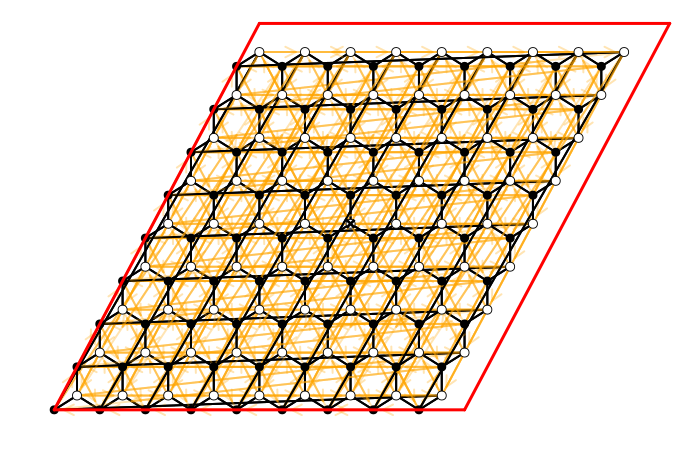

In [49]:
viz_enabled = true # show visualization of the Hamiltonian
if viz_enabled
    visualize_pbc(h,t,tp,Δ,0)
end

### Symmetries

In this section, we construct operators implementing several symmetries of $h$ and verify that they are indeed symmetries.

#### Translation

We define translation operators along the two primitive lattice vectors, which we denote $T_{\vec{a}_1}$ and $T_{\vec{a}_2}$.

In [ ]:
Ta1 = zeros(L_tot,L_tot)
for j in 1:length(row_lengths)
    len = row_lengths[j]
    for i in 1:len
        ind1 = idx(i,j)
        ind2 = idx(mod1(i+2,len),j)
        
        Ta1[ind2,ind1] = 1
    end
end

Ta2 = zeros(L_tot,L_tot)
for j in 1:length(row_lengths)
    len = row_lengths[j]
    for i in 1:len
        ind1 = idx(i,j)
        ind2 = idx(i,mod1(j+1,length(row_lengths)))
        
        Ta2[ind2,ind1] = 1
    end
end

Let's verify that $T_{\vec{a}_1}$ and $T_{\vec{a}_2}$ are unitary:

In [ ]:
Ta1_unitary = norm(Ta1*Ta1'-I)<1e-8
Ta2_unitary = norm(Ta2*Ta2'-I)<1e-8

display(latexstring("T_{\\vec{a}_1}\\;\\mathrm{unitary}?:\\; \\mathrm{$Ta1_unitary}"))
display(latexstring("T_{\\vec{a}_2}\\;\\mathrm{unitary}?:\\; \\mathrm{$Ta2_unitary}"))


We now show that $h$ is symmetric under $T_{\hat x}$ and $T_{\hat y}$ by computing that the commutators $[h,T_{\hat x/\hat y}]$ vanish:

In [ ]:
Ta1_comm = norm(h*Ta1-Ta1*h)
Ta2_comm = norm(h*Ta2-Ta2*h)

display(latexstring("|[h,T_{\\vec{a}_1}]|:\\;$Ta1_comm"))
display(latexstring("|[h,T_{\\vec{a}_2}]|:\\;$Ta2_comm"))

#### Rotation

There are three inequivalent threefold rotation symmetries of the honeycomb lattice, denoted $C_{3,o}$ where $o=A$ ,$B$, and $C$. These symmetries act as
$$C_{3,o} c_{\vec\imath,\sigma} C_{3,o}^\dagger  = e^{i\lambda^{3,o}_{\vec\imath}}c_{R^o_{2\pi/3}(\vec\imath),\sigma},$$
where $R^o_{2\pi/3}(\vec\imath)$ is the coordinate obtained by rotating $\vec\imath$ by $2\pi/3$ radians about the point $o$ and $e^{i\lambda^{3,o}_{\vec\imath}}$ is a site-dependent gauge transformation. We construct unitaries which implement these transformations on the first-quantized Hamiltonian:

In [ ]:
C3_A = make_rotation(origin_space_A);
C3_B = make_rotation(origin_space_B);
C3_C = make_rotation(origin_space_C);

Let's verify that the $C_{3,o}$ are unitary:

In [ ]:
C3_A_unitary = norm(C3_A*C3_A'-I)<1e-8
C3_B_unitary = norm(C3_B*C3_B'-I)<1e-8
C3_C_unitary = norm(C3_C*C3_C'-I)<1e-8


display(latexstring("C_{3,A}\\;\\mathrm{unitary}?:\\; \\mathrm{$C3_A_unitary}"))
display(latexstring("C_{3,B}\\;\\mathrm{unitary}?:\\; \\mathrm{$C3_B_unitary}"))
display(latexstring("C_{3,C}\\;\\mathrm{unitary}?:\\; \\mathrm{$C3_C_unitary}"))


Let's show that $h$ has all three $C_{3,o}$ symmetries:

In [ ]:
C3_A_comm = norm(h*C3_A-C3_A*h)
C3_B_comm = norm(h*C3_B-C3_B*h)
C3_C_comm = norm(h*C3_C-C3_C*h)

display(latexstring("|[h,C_{3,A}]|:\\;$C3_A_comm"))
display(latexstring("|[h,C_{3,B}]|:\\;$C3_B_comm"))
display(latexstring("|[h,C_{3,C}]|:\\;$C3_C_comm"))

### Diagonalization

In this section, we diagonalize $h$ and plot its spectrum.

In [ ]:
@time eigenvalues, eigenvectors = eigen(Matrix(h));

In [ ]:
window = 10 # number of eigenvalues to zoom in on
mu = 0.002 # should be slightly greater than zero so all zero-energy eigenstates are included

plot1 = plot(eigenvalues,seriestype=:scatter, ms=1, ma=0.5,legend=false)
plot!(zeros(L_tot) .+ mu, c=:black)
xlabel!("Eigenvalue Number")
ylabel!("Energy")

plot2 = plot(eigenvalues[Int(L_tot/2)-window:1:Int(L_tot/2)+window],seriestype=:scatter, ms=2, ma=0.5,legend=false)
plot!(zeros(2*window+1).+ mu, c=:black)
xlabel!("Eigenvalue Number")
ylabel!("Energy")

plot(plot1,plot2,layout=(1,2),size=(800,400),margin=5Plots.mm)

### Symmetry Eigenvalues

In this section, we compute eigenvalues of the Dirac fermion under various spatial symmetry operations. We first have to find the degenerate zero-energy subspace.

In [ ]:
zero_degen = length(findall(abs.(eigenvalues) .< 1e-5))
zero_eigs = eigenvectors[:,Int(L_tot/2-zero_degen/2+1):Int(L_tot/2+zero_degen/2)];

println("There are ",zero_degen," zero-energy eigenstates")

#### Rotations

We now construct the effective rotation operators in the zero-energy eigenspace:

In [ ]:
C3_A_mat = zero_eigs'*C3_A*zero_eigs;
C3_B_mat = zero_eigs'*C3_B*zero_eigs;
C3_C_mat = zero_eigs'*C3_C*zero_eigs;

Let's verify that they are still unitary matrices:

In [ ]:
C3_A_zero_unitary = norm(C3_A_mat*C3_A_mat'-I)<1e-9
C3_B_zero_unitary = norm(C3_B_mat*C3_B_mat'-I)<1e-9
C3_C_zero_unitary = norm(C3_C_mat*C3_C_mat'-I)<1e-9

display(latexstring("C_{3,A}|_{E=0}\\;\\mathrm{unitary}?:\\;\\mathrm{$C3_A_zero_unitary}"))
display(latexstring("C_{3,B}|_{E=0}\\;\\mathrm{unitary}?:\\;\\mathrm{$C3_B_zero_unitary}"))
display(latexstring("C_{3,C}|_{E=0}\\;\\mathrm{unitary}?:\\;\\mathrm{$C3_C_zero_unitary}"))

Diagonalizing the rotation symmetry action in the zero-energy eigenspace, we find the following eigenvalues:

In [ ]:
U = eigvecs((C3_A_mat));
display(round.(diag(U'*C3_A_mat*U),digits=2))
U = eigvecs((C3_B_mat));
display(round.(diag(U'*C3_B_mat*U),digits=2))
U = eigvecs((C3_C_mat));
display(round.(diag(U'*C3_C_mat*U),digits=2))

We know that there exists a basis in which the Dirac fermion transforms under rotations as
$$C_{3,o}: \Psi_{\vec{k}_\star} \rightarrow e^{i\frac{2\pi}{3}s_o} \Lambda(2\pi/3)
     \Psi_{\vec{k}_\star}, $$
where $\Lambda(2\pi/3) = e^{i \frac{1}{2} \frac{2\pi}{3} \sigma^z}=\begin{pmatrix}e^{i\frac{\pi}{3}}&0\\0&e^{-i\frac{\pi}{3}}\end{pmatrix}$. 

We can therefore read off the value of $s_o$ for each Dirac fermion from the eigenvalues we have calculated.

## Gapped Calculations

In this section, we will find the topological invariants in the gapped phases via partial rotations.

### Parameter Input

We have four model parameters:
- L: determines size of lattice
- t: amplitude of nearest-neighbor hopping
- tp: amplitude of next-nearest-neighbor hopping
- Δ: staggered on-site potential

In [66]:
# Model Parameters
L = 4
t = 1 # NN Amplitude
tp = 6 # NNN Amplitude
Δ = 1.299 # Amplitude of staggered potential

viz_enabled = true;

In [67]:
# Defining variables
L_max = 4*L+1
L_min = L_max-2*L

row_lengths = vcat(L_min:2:(L_max+1),L_max:-2:(L_min+1))

L_tot = sum(row_lengths)

yo = Int(ceil((length(row_lengths))/2))
xo = Int(ceil((row_lengths[yo]/2)))
origin = [xo,yo];

We construct the first quantized Hamiltonian $h$, defined so that
$$H=\sum_{i,j}c^\dagger_i h_{ij} c_j,$$
on a lattice with open boundary conditions.

In [78]:
h = obc_hamiltonian(L, Δ, tp, t, 0);

As a consistency check, we verify that the Hamiltonian is Hermitian:

In [79]:
ishermitian(h)

true

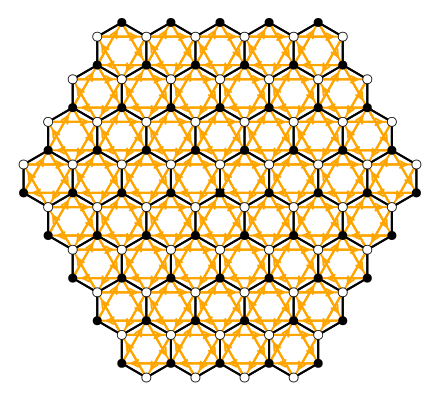

In [80]:
if viz_enabled
    visualize_obc(h,t,tp,Δ,0)
end

Let's show that this model has a threefold rotation symmetry about its central vertex:

In [70]:
sites = []
for i in 1:L_tot
    push!(sites,[ind2space_obc(i)[1],ind2space_obc(i)[2]])
end
sites = hcat(sites...)

origin_space = ind2space_obc(idx(origin[1],origin[2]))

C3 = zeros((L_tot,L_tot))
for ind in 1:L_tot
    pt = ind2space_obc(ind)
    rot_pt = rot(origin_space, pt, 2*pi/3)
    distance = abs.(sites .- [rot_pt[1],rot_pt[2]])
    result_list = dropdims(sum(distance,dims=1),dims=1)
    rot_idx = argmin(result_list)
    C3[rot_idx,ind] = 1
end

We can verify that the rotation transformation is unitary, cubes to the identity, and is a symmetry of $h$.

In [71]:
C3_unitary = norm(C3*C3' - I) < 1e-9
C3_cubed = norm(C3*C3*C3 - I) < 1e-9
C3_comm = norm(C3*h-h*C3)

display(latexstring("(C_3)^3=I?:\\;\\mathrm{$C3_cubed}"))
display(latexstring("C_3\\;\\mathrm{unitary}?:\\;\\mathrm{$C3_unitary}"))
display(latexstring("|[C_3,h]|:\\;$C3_comm"))

L"$(C_3)^3=I?:\;\mathrm{true}$"

L"$C_3\;\mathrm{unitary}?:\;\mathrm{true}$"

L"$|[C_3,h]|:\;0.0$"

### Diagonalization

In this section, we diagonalize $h$ and plot its spectrum. This time, we will see a gapped bulk spectrum, possibly with an edge mode if we are tuned to a phase with nonzero $C$.

In [ ]:
@time eigenvalues, eigenvectors = eigen(Matrix(h));

In [ ]:
mu = 0.002
window = 10

plot1 = scatter(eigenvalues, ms=1, cmap=cgrad([:black,:red,:blue,:black]), markerstrokewidth=0)
plot!(zeros(L_tot) .+ mu, c=:black)
xlabel!("Eigenvalue Number")
ylabel!("Energy")

plot2 = scatter(eigenvalues[Int(round(L_tot/2))-window:1:Int(round(L_tot/2))+window], ms=4, cmap=cgrad([:black,:red,:blue,:black]), markerstrokewidth=0)
plot!(zeros(2*window+1).+ mu, c=:black)
xlabel!("Eigenvalue Number")
ylabel!("Energy")

plot(plot1,plot2,layout=(1,2),size=(800,400),margin=5Plots.mm,legend=:false)

### Partial Rotations

In this section, we will calculate topological invariants in the gapped phases via partial rotations. Throughout we will reference definitions and formulae from arXiv:2303.16919.

We first need to construct a rotation-invariant set of sites.

In [ ]:
origin_space = ind2space_obc(idx(origin[1],origin[2]))

D_indices = []
R = 10 # radius of restriction
# needs to be small enough to not extend beyond lattice

for i in -(R+1):R+1
    for j in -R:R
        pt = ind2space_obc(idx(origin[1]+i,origin[2]+j))
        rot_pt = rot(origin_space, pt, 2*pi/3)
        distance = abs.(sites .- [rot_pt[1],rot_pt[2]])
        result_list = dropdims(sum(distance,dims=1),dims=1)
        rot_idx = argmin(result_list)
        push!(D_indices,rot_idx)
    end
end

for _ in 1:3
    for i in D_indices
        pt = ind2space_obc(i)
        rot_pt = rot(origin_space, pt, 2*pi/3)
        distance = abs.(sites .- [rot_pt[1],rot_pt[2]])
        result_list = dropdims(sum(distance,dims=1),dims=1)
        rot_idx = argmin(result_list)
        push!(D_indices,rot_idx)
        D_indices = union(D_indices)
    end
end

We can visualize the region we have constructed

In [ ]:
p1 = plot(legend=false,size=(700,600))

for ind in 1:L_tot
    pt = ind2space_obc(ind)
    scatter!([pt[1]],[pt[2]],color=:black)
end

for ind in D_indices
    pt = ind2space_obc(ind)
    scatter!([pt[1]],[pt[2]],color=:red)
end

display(p1)

In [ ]:
not_D_indices = setdiff(1:L_tot,D_indices);

We will construct the symmetries $C_{3,\chi}^{+}$ and $C_{3,\chi}^{-}$ restricted to the region we have defined. These are both symmetries of $h$, but one is order-three while the other is order-six.

We can then extract universal information via the formula:
\begin{equation*}
   \bra{\Psi}C_{M,o,\chi}^{\pm}|_D\ket{\Psi}=e^{\frac{2\pi i}{M}l_{D,o,\chi}^{\pm}-\gamma_{D,o,\chi}^{\pm}},
\end{equation*}
where $\gamma_{D,o,\chi}^{\pm}\propto \partial D$ sets the real-valued amplitude and $l_{D,o,\chi}^{\pm}$ encodes the topological data. In particular, $l_{D,o,\chi}^{\pm}$ satisfies
\begin{equation}
    l_{D,o,\chi}^{\pm}= \frac{C \chi^2}{2} + \mathcal{S}_o^{\pm}\chi + K_o^{\pm}\text{ mod }M.
\end{equation}

In [ ]:
# Construct chi-dependent matrix
χ_list = 0:2
C_tilde_plus_list = []
C_tilde_minus_list = []
l_plus_list = []
l_minus_list = []

filled_indices = findall(real(eigenvalues) .< mu);
filled_levels = eigenvectors[:,filled_indices];

mask = zeros((L_tot,L_tot))
for i in D_indices
    for j in D_indices
        mask[i,j] = 1
    end
end

for χ in χ_list    
    C3_partial_plus = exp(im*2*pi*χ/3)* C3 .* mask
    for i in not_D_indices
        C3_partial_plus[i,i] = 1
    end

    C3_minus = exp(im*2*pi*χ/3)*exp(im*pi/3)*C3
    C3_partial_minus = C3_minus.*mask
    for i in not_D_indices
        C3_partial_minus[i,i] = 1
    end
    
    # Find expectation value
    expect_C_tilde_plus_chi_D = det(filled_levels' * C3_partial_plus * filled_levels)
    expect_C_tilde_minus_chi_D = det(filled_levels' * C3_partial_minus * filled_levels)
    
    l_plus = 3*angle(expect_C_tilde_plus_chi_D)/(2*pi)
    l_minus = 3*angle(expect_C_tilde_minus_chi_D)/(2*pi)
    
    push!(C_tilde_plus_list,expect_C_tilde_plus_chi_D)
    push!(C_tilde_minus_list,expect_C_tilde_minus_chi_D)
    push!(l_plus_list,l_plus)
    push!(l_minus_list,l_minus)
end

In [ ]:
Theta_plus = mod(l_plus_list[1],3)
Theta_minus = mod(l_minus_list[1],1.5)
C = -1
S = mod((2*(Theta_minus-Theta_plus))-C/2,3)

display(latexstring("\\Theta^+:\\;$Theta_plus"))
display(latexstring("\\Theta^-:\\;$Theta_minus"))
display(latexstring("\\mathcal{S}:\\;$S"))

#### Fitting to the $l$ vs $\chi$ curve

Let's fit a quadratic polynomial mod 3 to the $\langle \Psi|C^+_{3,\chi}|\Psi\rangle$ vs. $\chi$ data. We tune by hand $C$, $\mathcal{S}^+$, and $K^+$ to fit the data.

In [ ]:
## These parameters should be tuned by hand to interpolate the data
S_plus = S
K_plus = 1/3

scatter(χ_list,mod.(l_plus_list,3),ylims=(0,3),label="Measured Values")
plot!(χ_list,mod.((C/2)*(χ_list.^2) .+ S_plus*χ_list .+ K_plus,3),label="Fit")

xlabel!(L"\chi")
ylabel!(L"C_{3,\chi}^+")

Now, let's fit a quadratic polynomial mod 3 to the $\langle \Psi|\tilde C^-_{3,\chi}|\Psi\rangle$ vs. $\chi$ data:

In [ ]:
## These parameters should be tuned by hand to interpolate the data
S_minus= 0
K_minus = 11/6

scatter(χ_list,mod.(l_minus_list,3),ylims=(0,3),label="Measured Values")
plot!(χ_list,mod.((C/2)*χ_list.^2+S_minus*χ_list.+K_minus,3),label="Fit")
plot!(χ_list,mod.((C/2)*χ_list.^2+S_minus*χ_list.+K_minus.+1.5,3),label="(Fit + 1.5) mod 3")

xlabel!(L"\chi")
ylabel!(L"C_{3,\chi}^-")

Now that we have $K^+$ and $K^-$, we can find $\Theta^+:=K^+ \text{ mod }3$ and $\Theta^-:=K^- \text{ mod }\frac{3}{2}$ and use 
$$2(\Theta^--\Theta^+)-\frac{C}{2}=\mathcal{S}^+\text{ mod }3$$
to extract the discrete shift $\mathcal{S}^+$ and the $M=3$ relation
$$\frac{11}{12}C+2\Theta_o\text{ mod }3$$
to extract $\ell$.

In [ ]:
Theta_plus = mod(K_plus,3)
Theta_minus = mod(K_minus,3/2)

S = mod((2*(Theta_minus-Theta_plus))-C/2,3)

l = mod((11/12)*C + 2*Theta_plus,3)

display(latexstring("C:\\;$C\\qquad \\mathcal{S}:\\;$S\\qquad \\ell:\\;$l\\qquad \\Theta^+:\\;$Theta_plus\\qquad\\Theta^-:\\;$Theta_minus"))

# Defect Hamiltonians

In this section, we present the code for measuring the current and energy density in the Haldane model on a lattice with various crystalline defects.

## Disclinations

### Parameter Input

In [490]:
##### PARAMETERS #####
n = 6
tp = 1 # NNN Amplitude +-1
viz_enabled = false
disc_type = "Aplus"; # "A", "B", "C", or "Aplus"
######################

In [521]:
L = 2*n # Needs to be even
t = 1 # NN Amplitude
Δ = 1.299 # Amplitude of staggered potential
mu = 0.002 # chemical potential
δϕ = pi/4 # excess flux

if disc_type == "A"
    row_lengths = vcat(5:6:6*L+5,6*L+7:-2:6*L+7-2*L)
    L_subtotal = sum(row_lengths)
    L_tot = 2*L_subtotal+1

    yo = Int(ceil((length(row_lengths))/2))
    xo = Int(ceil((row_lengths[yo]/2)))
    origin_space = [0,0];

    h_fun = disc_hamiltonian_A
    h = disc_hamiltonian_A(L, Δ, tp, t, δϕ);
end

if disc_type == "B"
    row_lengths = vcat(5:6:6*L+5,6*L+7:-2:6*L+7-2*L)
    L_subtotal = sum(row_lengths)
    L_tot = 2*L_subtotal+1

    yo = Int(ceil((length(row_lengths))/2))
    xo = Int(ceil((row_lengths[yo]/2)))
    origin_space = [0,0];

    h_fun = disc_hamiltonian_B
    h = disc_hamiltonian_B(L, Δ, tp, t, δϕ);
end

if disc_type == "C"
    row_lengths = vcat(1:2:4*L+1)

    L_subtotal = sum(row_lengths)
    L_tot = 4*sum(row_lengths)

    origin_space = (0,0);
    h_fun = disc_hamiltonian_C
    h = disc_hamiltonian_C(L, Δ, tp, t, δϕ);
end

if disc_type == "Aplus"
    row_lengths = vcat(5:6:6*L+5,6*L+7:-2:6*L+7-2*L)
    L_subtotal = sum(row_lengths)
    L_tot = 4*L_subtotal+1

    yo = Int(ceil((length(row_lengths))/2))
    xo = Int(ceil((row_lengths[yo]/2)))
    origin_space = [0,0];

    h_fun = disc_hamiltonian_Aplus
    h = disc_hamiltonian_Aplus(L, Δ, tp, t, δϕ);
end

if viz_enabled
    H_graph = h_fun(L, 0, 0, 1, 0);
    g = SimpleDiGraph(abs.(Matrix(H_graph)))
    indices = hcat(spectral_layout_mine(g)...);
end;

LoadError: InterruptException:

In [492]:
ishermitian(h)

true

In [493]:
if viz_enabled
    disc_visualize(h,t,tp,Δ,δϕ)
end

### Generating Data

Here, we calculate the current and energy density in the disclination lattice.

In [494]:
## Iterating over flux inserted at disclination core ##
data_list = []; H_list = [];
δϕs = 0:0.2:2*pi
@showprogress for δϕ in δϕs
    H = h_fun(L, Δ, tp, t, δϕ);
    
    eigenvalues, eigenvectors = eigen(Matrix(H));

    filled_number = count(x -> x < mu, eigenvalues);
    filled_levels = eigenvectors[:,1:filled_number];

    c_ia1 = [];c_ima1 = [];c_ia2 = [];c_ima2 = [];

    global x_pos = []
    global y_pos = []

    global x_distances_1 = []
    global y_distances_1 = []
    
    global uc_indices_A = []
    global uc_indices_B = []

    δϕ_vec = [];

    for j in 2:length(row_lengths)
        len = row_lengths[j]
        for i in 4:2:len
            if disc_type == "C"
                ia1 = disc_idx(i,j,1); ima1 = disc_idx(i-1,j,1); ia2 = disc_idx(i,j,1); ima2 = disc_idx(i-1,j-1,1);
            elseif j <= length(row_lengths)/2
                ia1 = disc_idx(i,j,1); ima1 = disc_idx(i-1,j,1); ia2 = disc_idx(i,j,1); ima2 = disc_idx(i-3,j-1,1);
            elseif j == length(row_lengths)/2+1
                ia1 = disc_idx(i-1,j,1); ima1 = disc_idx(i-2,j,1); ia2 = disc_idx(i-1,j,1); ima2 = disc_idx(i-1,j-1,1);
            else
                ia1 = disc_idx(i-1,j,1); ima1 = disc_idx(i-2,j,1); ia2 = disc_idx(i-1,j,1); ima2 = disc_idx(i,j-1,1);
            end
            
            push!(uc_indices_A,ia1); 
            push!(uc_indices_B,ima1);

            push!(c_ia1,filled_levels[ia1,:]); push!(c_ima1,filled_levels[ima1,:]); 
            push!(c_ia2,filled_levels[ia2,:]); push!(c_ima2,filled_levels[ima2,:]);

            x, y = ind2space_original(ia1)
            push!(x_distances_1, x); push!(y_distances_1, y);
            push!(δϕ_vec,1);
        end
    end

    c_ia1 = hcat(c_ia1...);
    c_ima1 = hcat(c_ima1...);
    c_ia2 = hcat(c_ia2...);
    c_ima2 = hcat(c_ima2...);

    cc_ma1i = transpose(sum(c_ima1 .* conj(c_ia1),dims=1));
    cc_ima1 = transpose(sum(c_ia1 .* conj(c_ima1),dims=1));

    cc_ma2i = transpose(sum(c_ima2 .* conj(c_ia2),dims=1));
    cc_ima2 = transpose(sum(c_ia1 .* conj(c_ima2),dims=1));

    Ja1 = im*t*(cc_ma1i-cc_ima1);
    Ja2 = im*t*(cc_ma2i-cc_ima2);

    Jx_total = Ja1+0.5*Ja2;
    Jy_total = sqrt(3)*Ja2;

    global Jθ_micro_1 = -y_distances_1.*(Jx_total)+x_distances_1.*(Jy_total);
    
    push!(data_list,Jθ_micro_1)
    
    ## Local energy density ##
    local_H = diag(filled_levels*filled_levels'*H);
    
    A_indices = []; B_indices = [];
    H_i_list = []; H_j_list = [];
    for j in 2:length(row_lengths)
        len = row_lengths[j]
        for i in 4:2:len
            push!(A_indices,disc_idx(i,j,1))
            push!(B_indices,disc_idx(i+1,j,1))

            push!(H_i_list,i); push!(H_j_list,j);
        end
    end
    
    global local_H_sum = local_H[A_indices] .+ local_H[B_indices];
        
    push!(H_list,local_H_sum)

    vals = [];
    global H_x_distances = []; global H_y_distances = [];
    for ind in 1:length(local_H_sum)
        i = H_i_list[ind]; j = H_j_list[ind];
        x, y = ind2space_original(disc_idx(i,j,1))
        push!(vals,real(local_H_sum[ind]))
        push!(H_x_distances,x); push!(H_y_distances,y);
    end

    if viz_enabled
        s = scatter(H_x_distances, H_y_distances, zcolor=vals, marker=:circle, cmap=cgrad([:black,:red,:yellow,:white]), markersize=5,legend=true,size=((800,500)),markerstrokewidth=0, clims=(-2.14,-2.137))
        display(s)
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:24:27


In [497]:
data_tensor = real.(cat(data_list...; dims=2));
H_data_tensor = real.((hcat(H_list...)));

### Choosing sites to plot

In this section, we extract indices which are in the bulk of the lattice, neither too close to the defect core nor the edge, to include in our final plot.

In [498]:
## PARAMETERS ##
x_min_scale = -0.1; x_max_scale = 0.1; # in [-0.5,0.5]
y_min_scale = -0.2; y_max_scale = -0.1; # in [-0.5,0.0]
################

if (x_min_scale >= x_max_scale)|(y_min_scale >= y_max_scale)
    error("ERROR: Invalid bounds")
end

meas_indices = []
for i in 1:length(Jθ_micro_1)
    x = x_distances_1[i]
    y = y_distances_1[i]
        
    x_max = maximum(x_distances_1); x_min = minimum(x_distances_1); x_range = x_max - x_min;
    y_max = maximum(y_distances_1); y_min = minimum(y_distances_1); y_range = y_max - y_min;    
    
    if (x>x_min+x_range/2+x_min_scale*x_range)&&(x<x_min+x_range/2+x_max_scale*x_range)&&(y>y_min+y_range/2+y_min_scale*y_range)&&(y<y_min+y_range/2+y_max_scale*y_range)
        push!(meas_indices,i)
    end
end

H_meas_indices = []
for i in 1:length(local_H_sum)
    x = H_x_distances[i]
    y = H_y_distances[i]
        
    x_max = maximum(H_x_distances); x_min = minimum(H_x_distances); x_range = x_max - x_min;
    y_max = maximum(H_y_distances); y_min = minimum(H_y_distances); y_range = y_max - y_min;    
    
    if (x>x_min+x_range/2+x_min_scale*x_range)&&(x<x_min+x_range/2+x_max_scale*x_range)&&(y>y_min+y_range/2+y_min_scale*y_range)&&(y<y_min+y_range/2+y_max_scale*y_range)
        push!(H_meas_indices,i)
    end
end

if (length(meas_indices)== 0)|(length(H_meas_indices) == 0) 
    error("ERROR: No sites in specified range. Increase system size or range cutoff.")
else 
    n_sites = length(meas_indices)
    println("There are $n_sites sites in the specified range")
end

There are 15 sites in the specified range


### Finding zeros and extrema

We now find the zero crossings of the current and the minima and maxima of the energy density as a function of applied flux $\delta\alpha$. 

In [499]:
x_intercept_list = []

for ind in meas_indices
    xs = δϕs
    ys = data_tensor[ind,:]

    old_sign = ys[end]/abs(ys[end])
    for i in 1:length(ys)
        new_sign = ys[i]/abs(ys[i])
        if old_sign < 0 && new_sign > 0
            global flip = i
        end
        old_sign = copy(new_sign)
    end

    m = (ys[flip]-ys[flip-1])/(xs[flip]-xs[flip-1])
    b = ys[flip-1]

    Δx = -ys[flip-1]/m

    x_intercept = xs[flip-1]+Δx
    
    push!(x_intercept_list,x_intercept)
end

circular_mean(x_intercept_list)

5.164896396317487

In [500]:
other_x_intercept_list = []

for ind in meas_indices
    xs = δϕs
    ys = data_tensor[ind,:]

    old_sign = ys[end]/abs(ys[end])
    for i in 1:length(ys)
        new_sign = ys[i]/abs(ys[i])
        if old_sign > 0 && new_sign < 0
            global flip = i
        end
        old_sign = copy(new_sign)
    end

    mod((xs[flip]-xs[mod1(flip-1,length(ys))]),2*pi)

    m = (ys[flip]-ys[mod1(flip-1,length(ys))])/mod((xs[flip]-xs[mod1(flip-1,length(ys))]),2*pi)
    b = ys[mod1(flip-1,length(ys))]

    Δx = -ys[mod1(flip-1,length(ys))]/m
    
    x_intercept = xs[mod1(flip-1,length(ys))]+Δx
    
    push!(other_x_intercept_list,x_intercept)
end

circular_mean(other_x_intercept_list)

2.8609277947722664

In [501]:
max_list = []
for i in H_meas_indices
    peak = argmax(H_data_tensor[i,:])
    xs = collect(δϕs)[max(peak-2,1):min(peak+2,length(δϕs))]; ys = H_data_tensor[i,max(peak-2,1):min(peak+2,length(δϕs))];
    
    model(x, p) = p[1]*(x).^2 .+ p[2]*(x) .+ p[3]
    p0 = ones(3)

    fit = curve_fit(model, xs, ys, p0)
    fitted_params = fit.param
    
    xfit = range(minimum(xs), maximum(xs), length=1000)  # Smooth x range
    yfit = model(xfit, fitted_params)  # Corresponding y values

    # Plot the data and the fit
    s = scatter(xs, ys, label="Data", color=:blue, legend=:topleft)
    plot!(xfit, yfit, label="Fit", color=:red, linewidth=2)
    
    push!(max_list,xfit[argmax(yfit)])

    # display(s)
end

max_list = adjust_angles(max_list)

circular_mean(max_list)

2.3576029250820936

In [502]:
min_list = []
for i in H_meas_indices
    peak = argmin(H_data_tensor[i,:])
    xs = collect(δϕs)[max(peak-2,1):min(peak+2,length(δϕs))]; ys = H_data_tensor[i,max(peak-2,1):min(peak+2,length(δϕs))];
    
    model(x, p) = p[1]*(x).^2 .+ p[2]*(x) .+ p[3]
    p0 = ones(3)

    fit = curve_fit(model, xs, ys, p0)
    fitted_params = fit.param
    
    xfit = range(minimum(xs), maximum(xs), length=1000)  # Smooth x range
    yfit = model(xfit, fitted_params)  # Corresponding y values

    # Plot the data and the fit
    s = scatter(xs, ys, label="Data", color=:blue, legend=:topleft)
    plot!(xfit, yfit, label="Fit", color=:red, linewidth=2)
    
    push!(min_list,xfit[argmin(yfit)])

    # display(s)
end

circular_mean(min_list)

5.399017855553427

### Plotting

When we calculate the energy density, it comes with an arbitrary additive constant. In the following cell, we determine the true zero point of the energy density by finding where the energy density curves coalesce.

In [503]:
δϕs_refined = 0.1:0.01:2*pi-0.1
H_data_tensor_refined = zeros((length(H_meas_indices),length(δϕs_refined)))

for i in 1:length(H_meas_indices)
    H_data_tensor_refined[i,:] = [interpolate_y(δϕs, H_data_tensor[H_meas_indices[i],:], x_new) for x_new in δϕs_refined]
end
    
coal_ind = argmin(vec(maximum(H_data_tensor_refined,dims=1).-minimum(H_data_tensor_refined,dims=1)))

y_shift = mean(H_data_tensor_refined[:,coal_ind]);

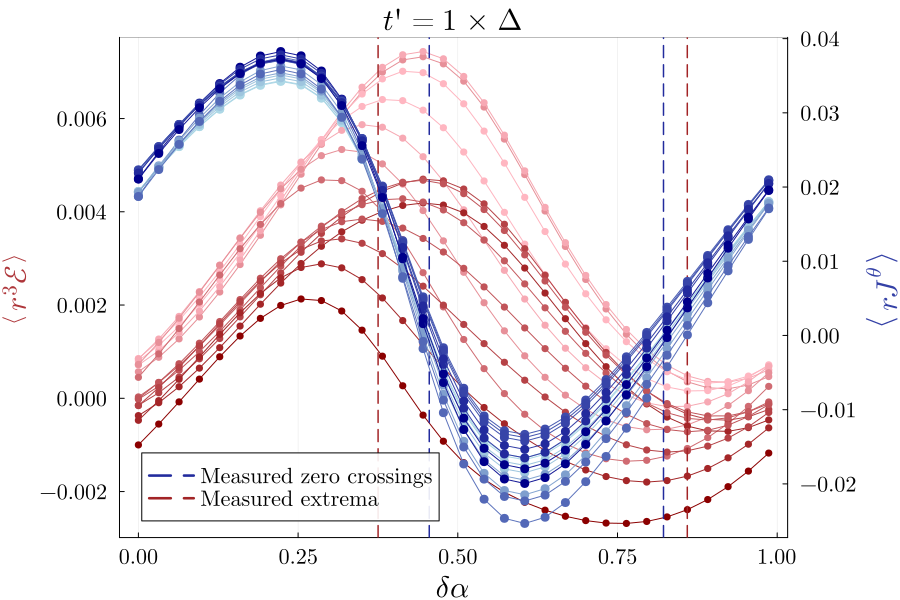

In [504]:
p = plot(size=(900,600),xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), legendfont=font("Computer Modern", 14),legend=:bottomleft,titlefont=font("Computer Modern",20), background_color_legend=RGBA(1,1,1,0.9))

x_origin = 0
y_origin = 0

x_meas_s = [H_x_distances[i] for i in H_meas_indices]
y_meas_s = [H_y_distances[i] for i in H_meas_indices]

distances = sqrt.((x_meas_s.-x_origin).^2 .+ ((y_meas_s.-y_origin).^2)')

min_dist = minimum(distances)
max_dist = maximum(distances)

power = 3
for i in H_meas_indices
    x_meas = H_x_distances[i]; y_meas = H_y_distances[i]; 
    distance = sqrt((x_meas-x_origin)^2+(y_meas-y_origin)^2)

    my_color = cgrad(:reds)[(distance-min_dist)/(max_dist-min_dist)]
    plot!(δϕs./(2*pi),(distance^power).*(H_data_tensor[i,:].-y_shift),label=false,color=my_color,xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), alpha=1.0, yformatter=:plain,yguidefontcolor=cgrad(:reds)[0.7],framestyle=:box,guidefont=font(20))
    scatter!(δϕs./(2*pi),(distance^power).*(H_data_tensor[i,:].-y_shift),label=false,zcolor=distance,markerstrokewidth=0.0,colormap=:reds, markersize=4,colorbar=false,alpha=1.0)
end

p_twin = twinx(p)

x_meas_s = [x_distances_1[i] for i in meas_indices]
y_meas_s = [y_distances_1[i] for i in meas_indices]

distances = sqrt.((x_meas_s.-x_origin).^2 .+ ((y_meas_s.-y_origin).^2)')

min_dist = minimum(distances)
max_dist = maximum(distances)

max_value = -1e5; min_value = 1e5;

power = 1
for i in meas_indices
    x_meas = x_distances_1[i]; y_meas = y_distances_1[i]; 
    distance = sqrt((x_meas-x_origin)^2+(y_meas-y_origin)^2)
    my_color = cgrad(:blues)[(distance-min_dist)/(max_dist-min_dist)]
    plot!(p_twin,δϕs./(2*pi),(distance^power).*(data_tensor[i,:]),label=false,color=my_color,xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14),yguidefontcolor=cgrad(:blues)[0.7],guidefont=font(20))
    scatter!(p_twin,δϕs./(2*pi),(distance^power).*(data_tensor[i,:]),label=false,zcolor=distance,markerstrokewidth=0,colormap=:blues, markersize=5, colorbar=false)

    rJθ = (distance^power).*(data_tensor[i,:]); push!(rJθ,max_value); max_value = maximum(rJθ);
    rJθ = (distance^power).*(data_tensor[i,:]); push!(rJθ,min_value); min_value = minimum(rJθ);
end

## Negative to Positive ##
vline!([circular_mean(x_intercept_list)/(2*pi)], linestyle=:dash, color=cgrad(:blues)[0.8], label="Measured zero crossings", lw=1.5)
vline!([circular_mean(min_list)/(2*pi)], linestyle=:dash, color=cgrad(:reds)[0.8], label="Measured extrema", lw=1.5)

## Positive to Negative ##
vline!([circular_mean(other_x_intercept_list)/(2*pi)], linestyle=:dash, color=cgrad(:blues)[0.8], label=false, lw=1.5)
vline!([circular_mean(max_list)/(2*pi)], linestyle=:dash, color=cgrad(:reds)[0.8], label=false, lw=1.5)
        
xlabel!(p,L"\delta\alpha")
ylabel!(p,L"\left\langle r^3\mathcal{E} \right\rangle")

xlabel!(p_twin,"")
ylabel!(p_twin,L"\left\langle rJ^\theta \right\rangle")

title!(p,latexstring("t'=$tp\\times\\Delta"))
title!(p_twin,"")

plot!(p,left_margin = 2Plots.mm,right_margin = 3Plots.mm,framestyle=:semi)

display(p)

## Dislocation

### Parameter Input

In [606]:
##### PARAMETERS #####
n = 14 ## 14, 20, 26
tp = -1 # NNN Amplitude +-1
viz_enabled = false;
######################

In [607]:
L = 4*n
t = 1 # NN Amplitude
Δ = 1.29904 # Amplitude of staggered potential
mu = 0.002 # chemical potential
δϕ = pi/4 # excess flux

row_lengths = vcat([L+1 for _ in 1:(L/2)],L,[L+1 for _ in 1:(L/2)])
L_tot = Int(sum(row_lengths))

yo = Int(ceil((length(row_lengths))/2))
xo = Int(ceil((row_lengths[yo]/2)))
origin = [xo,yo];

h_fun = disloc_hamiltonian
h = disloc_hamiltonian(L, Δ, tp, t, δϕ);

In [608]:
ishermitian(h)

true

In [609]:
if viz_enabled
    disloc_visualize(h,t,tp,Δ,δϕ)
end

### Generating Data

Here, we calculate the current and energy density in a lattice with a dislocation.

In [610]:
data_list = []; H_list = [];

δϕs = 0:0.2:2*pi
@showprogress for δϕ in δϕs
    h = disloc_hamiltonian(L, Δ, tp, t, δϕ);

    eigenvalues, eigenvectors = eigen(Matrix(h));

    filled_number = count(x -> x < mu, eigenvalues);
    filled_levels = eigenvectors[:,1:filled_number];

    c_ia1 = [];c_ima1 = [];c_ia2 = [];c_ima2 = [];

    global x_pos = []
    global y_pos = []

    x_distances = []
    y_distances = []

    δϕ_vec = [];

    for j in Int.(length(row_lengths)/2+5/2:length(row_lengths))
        len = Int(row_lengths[j])
        for i in 2:2:len
            if (j%2==0)
                ia1 = disloc_idx(i,j); ima1 = disloc_idx(i-1,j); ia2 = disloc_idx(i,j); ima2 = disloc_idx(i,j-1);
            else
                ia1 = disloc_idx(i+1,j); ima1 = disloc_idx(i,j); ia2 = disloc_idx(i+1,j); ima2 = disloc_idx(i+1,j-1);
            end

            push!(c_ia1,filled_levels[ia1,:])
            push!(c_ima1,filled_levels[ima1,:])
            push!(c_ia2,filled_levels[ia2,:])
            push!(c_ima2,filled_levels[ima2,:])

            x, y = disloc_ind2space(ia1)
            push!(x_pos, x); push!(y_pos, y);

            x = (-j)*sqrt(3)/2 + (i)*sqrt(3)/2
            y = 0.5 + (j-1)*1.5 
            push!(x_distances, x); push!(y_distances, y);
            push!(δϕ_vec,1);
        end
    end

    c_ia1 = hcat(c_ia1...);
    c_ima1 = hcat(c_ima1...);
    c_ia2 = hcat(c_ia2...);
    c_ima2 = hcat(c_ima2...);

    cc_ma1i = transpose(sum(c_ima1 .* conj(c_ia1),dims=1));
    cc_ima1 = transpose(sum(c_ia1 .* conj(c_ima1),dims=1));

    cc_ma2i = transpose(sum(c_ima2 .* conj(c_ia2),dims=1));
    cc_ima2 = transpose(sum(c_ia1 .* conj(c_ima2),dims=1));

    Ja1 = im*t*(cc_ma1i-cc_ima1);
    Ja2 = im*t*(cc_ma2i-cc_ima2);

    Jx_total = Ja1+0.5*Ja2;
    Jy_total = sqrt(3)*Ja2;

    global Jθ_micro = -y_pos.*(Jx_total)+x_pos.*(Jy_total);

    xs = []
    ys = []
    vals = []
    for i in 1:length(Jθ_micro)
        x = x_pos[i]; y = y_pos[i]; val = real.(Jθ_micro)[i];
        push!(xs,x); push!(ys,y); push!(vals,val);
    end

    s = scatter(xs, ys, zcolor=vals, marker=:circle, clim=(-5e-2,5e-2), cmap=cgrad([:black,:red,:yellow,:white]), markersize=5,legend=true,size=((800,500)),markerstrokewidth=0)
    
    # display(s)
    
    push!(data_list,Jθ_micro)
    
    ## Local energy density ##
    local_H = diag(filled_levels*filled_levels'*h);
    
    A_indices = []; B_indices = [];
    H_i_list = []; H_j_list = [];
    for j in Int.(length(row_lengths)/2+5/2:length(row_lengths))
        len = Int(row_lengths[j])
        for i in 2:2:len-2
            if (j%2==0)
                push!(A_indices,disloc_idx(i,j)); push!(B_indices,disloc_idx(i+1,j));
            else
                push!(A_indices,disloc_idx(i+1,j)); push!(B_indices,disloc_idx(i+2,j));
            end

            push!(H_i_list,i); push!(H_j_list,j);
        end
    end
    
    global local_H_sum = local_H[A_indices] .+ local_H[B_indices];
        
    push!(H_list,local_H_sum)

    vals = [];
    global H_x_distances = []; global H_y_distances = [];
    for ind in 1:length(local_H_sum)
        i = H_i_list[ind]; j = H_j_list[ind];
        x, y = disloc_ind2space(A_indices[ind])
        push!(vals,real(local_H_sum[ind]))
        push!(H_x_distances,x); push!(H_y_distances,y);
    end
    
    s = scatter(H_x_distances, H_y_distances, zcolor=vals, marker=:circle, cmap=cgrad([:black,:red,:yellow,:white]), markersize=5,legend=true,size=((800,500)),markerstrokewidth=0)
    # display(s)
end

Progress: 100%|█████████████████████████████████████████| Time: 0:04:59


In [611]:
data_tensor = real.(cat(data_list...; dims=2));
H_data_tensor = real.((hcat(H_list...)));

### Choosing sites to plot

In this section, we extract indices which are in the bulk of the lattice, neither too close to the defect core nor the edge, to include in our final plot.

In [612]:
## PARAMETERS ##
x_min_scale = 0.0; x_max_scale = 0.05; # in [0.,0.5]
y_min_scale = -0.42; y_max_scale = -0.32; # in [-0.5,0.0]
################

if (x_min_scale >= x_max_scale)|(y_min_scale >= y_max_scale)
    error("ERROR: Invalid bounds")
end

meas_indices = []
for i in 1:length(Jθ_micro)
    x = x_pos[i]
    y = y_pos[i]
        
    x_max = maximum(x_pos); x_min = minimum(x_pos); x_range = x_max - x_min;
    y_max = maximum(y_pos); y_min = minimum(y_pos); y_range = y_max - y_min;    
    
    if (x>x_min+x_range/2+x_min_scale*x_range)&&(x<x_min+x_range/2+x_max_scale*x_range)&&(y>y_min+y_range/2+y_min_scale*y_range)&&(y<y_min+y_range/2+y_max_scale*y_range)
        push!(meas_indices,i)
    end
end

if (length(meas_indices)== 0)
    error("ERROR: No sites in specified range. Increase system size or range cutoff.")
else 
    n_sites = length(meas_indices)
    println("There are $n_sites sites in the specified range")
end

There are 3 sites in the specified range


### Finding zeros and extrema

We now find the zero crossings of the current and the minima and maxima of the energy density as a function of applied flux $\delta\alpha$. 

In [613]:
x_intercept_list = []

for ind in meas_indices
    xs = δϕs
    ys = data_tensor[ind,:]

    old_sign = ys[end]/abs(ys[end])
    for i in 1:length(ys)
        new_sign = ys[i]/abs(ys[i])
        if old_sign < 0 && new_sign > 0
            global flip = i
        end
        old_sign = copy(new_sign)
    end

    m = (ys[flip]-ys[flip-1])/(xs[flip]-xs[flip-1])
    b = ys[flip-1]

    Δx = -ys[flip-1]/m

    x_intercept = xs[flip-1]+Δx
    
    push!(x_intercept_list,x_intercept)
end

circular_mean(x_intercept_list)

2.405981338868249

In [614]:
other_x_intercept_list = []

for ind in meas_indices
    xs = δϕs
    ys = data_tensor[ind,:]

    old_sign = ys[end]/abs(ys[end])
    for i in 1:length(ys)
        new_sign = ys[i]/abs(ys[i])
        if old_sign > 0 && new_sign < 0
            global flip = i
        end
        old_sign = copy(new_sign)
    end

    mod((xs[flip]-xs[mod1(flip-1,length(ys))]),2*pi)

    m = (ys[flip]-ys[mod1(flip-1,length(ys))])/mod((xs[flip]-xs[mod1(flip-1,length(ys))]),2*pi)
    b = ys[mod1(flip-1,length(ys))]

    Δx = -ys[mod1(flip-1,length(ys))]/m
    
    x_intercept = xs[mod1(flip-1,length(ys))]+Δx
    
    push!(other_x_intercept_list,x_intercept)
end

circular_mean(other_x_intercept_list)

5.021171951270485

In [615]:
max_list = []
for i in meas_indices
    peak = argmax(H_data_tensor[i,:])
    xs = collect(δϕs)[max(peak-2,1):min(peak+2,length(δϕs))]; ys = H_data_tensor[i,max(peak-2,1):min(peak+2,length(δϕs))];
    
    model(x, p) = p[1]*(x).^2 .+ p[2]*(x) .+ p[3]
    p0 = ones(3)

    fit = curve_fit(model, xs, ys, p0)
    fitted_params = fit.param
    
    xfit = range(minimum(xs), maximum(xs), length=1000)  # Smooth x range
    yfit = model(xfit, fitted_params)  # Corresponding y values

    # Plot the data and the fit
    s = scatter(xs, ys, label="Data", color=:blue, legend=:topleft)
    plot!(xfit, yfit, label="Fit", color=:red, linewidth=2)
    
    push!(max_list,xfit[argmax(yfit)])

    # display(s)
end

max_list = adjust_angles(max_list)

circular_mean(max_list)

4.698560174349258

In [616]:
min_list = []
for i in meas_indices
    peak = argmin(H_data_tensor[i,:])
    xs = collect(δϕs)[max(peak-2,1):min(peak+2,length(δϕs))]; ys = H_data_tensor[i,max(peak-2,1):min(peak+2,length(δϕs))];
    
    model(x, p) = p[1]*(x).^2 .+ p[2]*(x) .+ p[3]
    p0 = ones(3)

    fit = curve_fit(model, xs, ys, p0)
    fitted_params = fit.param
    
    xfit = range(minimum(xs), maximum(xs), length=1000)  # Smooth x range
    yfit = model(xfit, fitted_params)  # Corresponding y values

    # Plot the data and the fit
    s = scatter(xs, ys, label="Data", color=:blue, legend=:topleft)
    plot!(xfit, yfit, label="Fit", color=:red, linewidth=2)
    
    push!(min_list,xfit[argmin(yfit)])

    # display(s)
end

circular_mean(min_list)

1.4928942279378694

### Plotting

When we calculate the energy density, it comes with an arbitrary additive constant. In the following cell, we determine the true zero point of the energy density by finding where the energy density curves coalesce.

In [617]:
δϕs_refined = 0.1:0.01:2*pi-0.1
H_data_tensor_refined = zeros((length(meas_indices),length(δϕs_refined)))

for i in 1:length(meas_indices)
    H_data_tensor_refined[i,:] = [interpolate_y(δϕs, H_data_tensor[meas_indices[i],:], x_new) for x_new in δϕs_refined]
end
    
coal_ind = argmin(vec(maximum(H_data_tensor_refined,dims=1).-minimum(H_data_tensor_refined,dims=1)))

y_shift = mean(H_data_tensor_refined[:,coal_ind]);

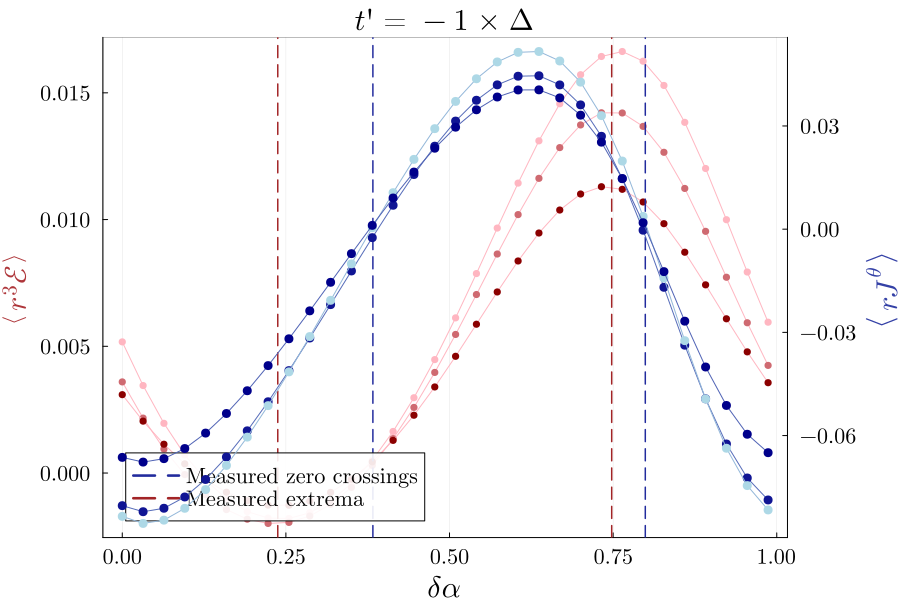

In [618]:
p = plot(size=(900,600),xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), legendfont=font("Computer Modern", 14),legend=:bottomleft,titlefont=font("Computer Modern",20), background_color_legend=RGBA(1,1,1,0.9))

x_origin = 0
y_origin = 0

x_meas_s = [H_x_distances[i] for i in H_meas_indices]
y_meas_s = [H_y_distances[i] for i in H_meas_indices]

distances = sqrt.((x_meas_s.-x_origin).^2 .+ ((y_meas_s.-y_origin).^2)')

min_dist = minimum(distances)
max_dist = maximum(distances)

power = 3
for i in meas_indices
    x_meas = H_x_distances[i]; y_meas = H_y_distances[i]; 
    distance = sqrt((x_meas-x_origin)^2+(y_meas-y_origin)^2)

    my_color = cgrad(:reds)[(distance-min_dist)/(max_dist-min_dist)]
    plot!(δϕs./(2*pi),(distance^power).*(H_data_tensor[i,:].-y_shift),label=false,color=my_color,xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14), alpha=1.0, yformatter=:plain,yguidefontcolor=cgrad(:reds)[0.7],framestyle=:box,guidefont=font(20))
    scatter!(δϕs./(2*pi),(distance^power).*(H_data_tensor[i,:].-y_shift),label=false,zcolor=distance,markerstrokewidth=0.0,colormap=:reds, markersize=4,colorbar=false,alpha=1.0)
end

p_twin = twinx(p)

x_meas_s = [x_distances_1[i] for i in meas_indices]
y_meas_s = [y_distances_1[i] for i in meas_indices]

distances = sqrt.((x_meas_s.-x_origin).^2 .+ ((y_meas_s.-y_origin).^2)')

min_dist = minimum(distances)
max_dist = maximum(distances)

max_value = -1e5; min_value = 1e5;

power = 1
for i in meas_indices
    x_meas = x_distances_1[i]; y_meas = y_distances_1[i]; 
    distance = sqrt((x_meas-x_origin)^2+(y_meas-y_origin)^2)
    my_color = cgrad(:blues)[(distance-min_dist)/(max_dist-min_dist)]
    plot!(p_twin,δϕs./(2*pi),(distance^power).*(data_tensor[i,:]),label=false,color=my_color,xtickfont=font("Computer Modern", 14), ytickfont=font("Computer Modern", 14),yguidefontcolor=cgrad(:blues)[0.7],guidefont=font(20))
    scatter!(p_twin,δϕs./(2*pi),(distance^power).*(data_tensor[i,:]),label=false,zcolor=distance,markerstrokewidth=0,colormap=:blues, markersize=5, colorbar=false)

    rJθ = (distance^power).*(data_tensor[i,:]); push!(rJθ,max_value); max_value = maximum(rJθ);
    rJθ = (distance^power).*(data_tensor[i,:]); push!(rJθ,min_value); min_value = minimum(rJθ);
end

## Negative to Positive ##
vline!([circular_mean(x_intercept_list)/(2*pi)], linestyle=:dash, color=cgrad(:blues)[0.8], label="Measured zero crossings", lw=1.5)
vline!([circular_mean(min_list)/(2*pi)], linestyle=:dash, color=cgrad(:reds)[0.8], label="Measured extrema", lw=1.5)

## Positive to Negative ##
vline!([circular_mean(other_x_intercept_list)/(2*pi)], linestyle=:dash, color=cgrad(:blues)[0.8], label=false, lw=1.5)
vline!([circular_mean(max_list)/(2*pi)], linestyle=:dash, color=cgrad(:reds)[0.8], label=false, lw=1.5)
        
xlabel!(p,L"\delta\alpha")
ylabel!(p,L"\left\langle r^3\mathcal{E} \right\rangle")

xlabel!(p_twin,"")
ylabel!(p_twin,L"\left\langle rJ^\theta \right\rangle")

title!(p,latexstring("t'=$tp\\times\\Delta"))
title!(p_twin,"")

plot!(p,left_margin = 2Plots.mm,right_margin = 3Plots.mm,framestyle=:semi)

display(p)